# Final Repeated Experiments E1-E10 and Native-Linux Investigation

This notebook is the self-contained analysis record for the final repeated-experiment campaign. It preserves the E2 command-channel causal investigation and extends the evidence analysis through the native command, telemetry, video, GUI, RC, flight, and recovery experiments. CSV/PCAP observations, protocol-conformance boundaries, and missing evidence are kept explicit so no separate blackout-investigation document is required.

E2 compares WSL2 and native command behavior; E3 extends that comparison to telemetry. E4-E9 evaluate the native stack from CLI video through GUI/RC flight and recovery. Captured and uncaptured conditions remain separate, and PCAP is used only when needed to localize an anomaly.

**Campaign result:** the periodic command blackout was confined to WSL2 in this dataset. Native Linux remained continuous in ordinary E2-E7 workloads and recovered in all recorded E8 power-cycle and E9 host-Wi-Fi interruption trials. The real-drone E10 terminal acceptance found the expected ROS 2 graph and two consecutive link-quality samples at score 100 with telemetry, video, and command classified OK; no ROS rate or active-RC benchmark was recorded.

## Investigation Purpose And Causal Question

The central question is:

> Are the periodic command-channel interruptions caused by the C++ API, WSL2/Windows networking, the Wi-Fi adapter or driver, the radio environment, or the DJI Tello itself?

The original WSL2 packet path was:

```text
tello_cli
  -> Linux UDP socket
  -> WSL virtual network interface
  -> WSL/Hyper-V networking or NAT
  -> Windows network stack and firewall
  -> Windows Wi-Fi driver
  -> physical Wi-Fi radio
  -> DJI Tello
```

The native-Linux reproduction removes the WSL virtual interface, Hyper-V, and Windows networking layers:

```text
tello_cli
  -> Linux UDP socket
  -> native Linux Wi-Fi stack and driver
  -> physical Wi-Fi radio
  -> DJI Tello
```

The experiment changes the operating-system/network-stack environment while keeping the command application, one-second query interval, 120-second duration, drone, stationary no-motor condition, and intended physical adapter path as similar as practical.

## Existing WSL2 Evidence And Its Boundary

The original environment reported kernel `6.18.33.2-microsoft-standard-WSL2`. Its dataset contains three uncaptured primary runs (`R01`-`R03`) and three captured diagnostic runs (`D01-PCAP`-`D03-PCAP`), each approximately 120 seconds with one `battery?` operation per second.

Across those six runs, ordinary command latency had approximately 32-34 ms per-run medians and 36-38.5 ms steady p95 values. Every public command ultimately succeeded, but every run contained a recovered multi-attempt interruption around 64-66 seconds. The three WSL2 PCAPs show blackout windows of approximately 2.401-3.180 seconds: outgoing UDP requests remain visible at the WSL capture point while incoming command responses are absent, after which SDK recovery restores normal traffic. One uncaptured run also contains extra delayed responses away from the main periodic event.

This proves that the application called its UDP send path and that outgoing packets reached the **WSL capture interface**. It also proves that corresponding responses did not reach that same point during each captured blackout. It does **not** prove that the outgoing frames reached the physical adapter or were transmitted over the air. Therefore the WSL2 evidence alone cannot separate WSL/Hyper-V/NAT, Windows firewall or Wi-Fi management, Windows driver behavior, radio loss, or temporary drone silence.

## Native-Linux Reproduction Protocol

The native experiment uses six independent 120-second runs with `--interval-ms 1000`: three primary runs without capture and three diagnostic runs captured directly on the physical Wi-Fi interface. Captured and uncaptured runs are never pooled. The drone remains stationary with motors off, and no other Tello application may own UDP command port 8889.

Primary identifiers:

```text
E2-CMD-BASE-NATIVE-R01
E2-CMD-BASE-NATIVE-R02
E2-CMD-BASE-NATIVE-R03
```

Diagnostic identifiers and matched PCAPs:

```text
E2-CMD-BASE-NATIVE-D01-PCAP
E2-CMD-BASE-NATIVE-D02-PCAP
E2-CMD-BASE-NATIVE-D03-PCAP
```

Representative primary command:

```bash
./build/tello_core_native/tello_cli --watch \
  --interval-ms 1000 --duration-s 120 \
  --metrics-csv results/final_repeated/E2-CMD-BASE-NATIVE-R01.csv \
  --test-id E2-CMD-BASE-NATIVE-R01 \
  --scenario command-baseline-native-linux \
  --notes "native Linux; no pcap; independent repetition 1 of 3"
```

Representative physical-interface capture and diagnostic command:

```bash
sudo tcpdump -i wlx503eaa237a02 -nn -s 0 \
  'host 192.168.10.1 and udp' \
  -w results/final_repeated/pcap/E2-CMD-BASE-NATIVE-D01-PCAP.pcap

./build/tello_core_native/tello_cli --watch \
  --interval-ms 1000 --duration-s 120 \
  --metrics-csv results/final_repeated/E2-CMD-BASE-NATIVE-D01-PCAP.csv \
  --test-id E2-CMD-BASE-NATIVE-D01-PCAP \
  --scenario command-baseline-native-linux \
  --notes "native Linux; with pcap; diagnostic repetition 1 of 3"
```

The same pattern is repeated without overwriting outputs. Continuous interface counters, kernel logs, and NetworkManager logs were optional and were **not collected**, so exact driver or scan-event correlation is unavailable.

## Recorded Native Environment, Build, And Connectivity Gate

The native session was recorded on 2026-07-10.

| Item | Recorded value |
|---|---|
| Operating system | Ubuntu 20.04.6 LTS (Focal Fossa) |
| Kernel | `5.15.0-139-generic` on x86-64 |
| CMake | 3.16.3 |
| C++ compiler | GCC/G++ 9.4.0 |
| FFmpeg | 4.2-era Ubuntu libraries |
| Qt | Qt5 (`qtbase5-dev` 5.12.8) |
| Wi-Fi interface | `wlx503eaa237a02` |
| Wi-Fi MAC | `50:3e:aa:23:7a:02` |
| Wi-Fi mode / transmit power | managed / 13.00 dBm |
| Tello SSID / BSSID | `TELLO-B5ACD2` / `60:60:1f:b5:ac:d2` |
| Frequency / signal | 2432 MHz / -40 dBm |
| Host address | `192.168.10.3/24` |
| Route | `192.168.10.1` through `wlx503eaa237a02` |
| Ping gate | 3/3 replies, 0% loss, 2.143 ms mean RTT |

A clean native build used `cmake -S tello_core -B build/tello_core_native` followed by `cmake --build build/tello_core_native`. Ubuntu 20.04 required a source compatibility fallback from `AV_FRAME_FLAG_KEY` to the legacy FFmpeg `AVFrame::key_frame` field; this affects video frame metadata only and does not alter the command-channel path. Both offline tests passed. CMake 3.16-compatible test invocation is:

```bash
cmake -E chdir build/tello_core_native \
  ctest -L offline --output-on-failure
```

Before E2, `E1-SMOKE-CMD-NATIVE` passed: SDK initialization returned `OK`, `battery?` returned 18% on the first battery, the client remained `CONNECTED`, and the CSV recorded one success with zero failures/retries/timeouts. The battery was then replaced; a second pre-run smoke check returned 90%, after which the six E2 runs were executed.

### Native Build Prerequisites For Reproduction

Ubuntu 20.04, 22.04, and 24.04 are suitable for the standalone C++17 CLI. ROS is not required for E2. Install the standalone build and capture dependencies with:

```bash
sudo apt update
sudo apt install -y \
  build-essential cmake pkg-config \
  libavformat-dev libavcodec-dev libavutil-dev libswscale-dev \
  qtbase5-dev tcpdump iw
```

Qt is not required for the CLI-only E2 experiment, but Qt5 is the appropriate Control Panel dependency on Ubuntu 20.04; the CMake project also supports Qt6 where available. Do not reuse a WSL2 `build/` directory or WSL-linked binary. Configure a clean native build so the executable links against the native compiler, glibc, FFmpeg, Qt, and network stack.

## Evidence Inventory

All evidence is stored under `results/final_repeated/` relative to the repository root.

- E1 smoke gates: original and native CSVs.
- E2: three WSL2 and three native primary CSVs, three diagnostic CSV/PCAP pairs per environment.
- E3: three WSL2 primary CSVs, three WSL2 diagnostic CSV/PCAP pairs, and three native primary CSVs.
- E4: three native CLI video CSVs; no PCAP was triggered.
- E5: three GUI metrics CSVs and three matched state recordings.
- E6: three grounded-RC GUI metrics CSVs and three matched state recordings.
- E7: three flight GUI metrics CSVs and three matched state recordings.
- E8: three native drone power-cycle recovery CSVs.
- E9: three native host-Wi-Fi loss/reconnect CSVs.
- E10: operator terminal acceptance with the real drone, including node/topic/service discovery and two live `/tello/link_quality` messages; no CSV or rosbag rate/latency capture.
- Generated figures are under `results/final_repeated/analysis_images/`.

The notebook locates the evidence directory from the repository root, `results/`, or the notebook directory. Every table is recomputed from stored evidence; the independent experimental unit is one run.

## Analysis Rules

- The independent experimental unit is one run, not one command packet.
- Captured runs are not pooled with uncaptured primary runs.
- WSL2 and native-Linux runs remain separate environment conditions.
- `last_command_latency_ms` is the complete client-observed battery query duration, including retries, recovery, and any SDK-state assurance within that call.
- Median and p95 describe routine and upper-tail behavior. Maximum latency preserves transient-recovery evidence; a first-sample maximum may include SDK assurance and must be inspected before interpretation.
- Steady p95 includes only commands completed in one internal attempt.
- A final `OK` after internal timeouts is a recovered transient loss, not a final failure.
- PCAP proves what crossed the selected host capture interface. It cannot alone distinguish radio interference, driver receive loss, or temporary drone silence below/beyond that interface.
- Native command responses are filtered by **destination port 8889**. Filtering only `udp port 8889` would also include Tello telemetry sourced from port 8889 and delivered to host port 8890.
- Direct observations are stated separately from root-cause inference. The native session occurred later rather than as a randomized simultaneous OS experiment.

In [34]:
from pathlib import Path
import csv
import math
import re
import shutil
import statistics
import subprocess

import numpy as np
import matplotlib.pyplot as plt

for style_name in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid"):
    if style_name in plt.style.available:
        plt.style.use(style_name)
        break
plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

def resolve_data_dir():
    candidates = [
        Path.cwd() / "final_repeated",
        Path.cwd() / "results" / "final_repeated",
        Path.cwd().parent / "results" / "final_repeated",
    ]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate results/final_repeated.")

DATA_DIR = resolve_data_dir()
PCAP_DIR = DATA_DIR / "pcap"
FIGURE_DIR = DATA_DIR / "analysis_images"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Data directory: {DATA_DIR}")
print(f"Figures directory: {FIGURE_DIR}")

Data directory: /home/gabriel/CS-500/results/final_repeated
Figures directory: /home/gabriel/CS-500/results/final_repeated/analysis_images


In [35]:
# Matplotlib before 3.5 does not accept labels/formatting keywords in
# set_xticks/set_yticks. Keep the notebook executable on Ubuntu 20.04 while
# preserving the modern call form used by later Matplotlib releases.
import inspect
from matplotlib.axes import Axes

def add_tick_label_compatibility(method_name, label_method_name):
    original = getattr(Axes, method_name)
    if "labels" in inspect.signature(original).parameters:
        return

    def compatible(self, ticks, labels=None, **kwargs):
        result = original(self, ticks)
        if labels is not None:
            getattr(self, label_method_name)(labels, **kwargs)
        return result

    setattr(Axes, method_name, compatible)

add_tick_label_compatibility("set_xticks", "set_xticklabels")
add_tick_label_compatibility("set_yticks", "set_yticklabels")
plt.rcParams.update({
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
})

In [36]:
def read_csv_rows(path):
    with path.open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

def number(row, key, default=math.nan):
    try:
        return float(row[key])
    except (KeyError, TypeError, ValueError):
        return default

def percentile(values, q):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    return float(np.percentile(values, q)) if values.size else math.nan

def sample_sd(values):
    values = [float(value) for value in values if math.isfinite(float(value))]
    return statistics.stdev(values) if len(values) > 1 else 0.0

def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=170, bbox_inches="tight")
    print(f"Saved: {path}")
    return path

all_csv_paths = sorted(DATA_DIR.glob("E2-CMD-BASE-*.csv"))
wsl_csv_paths = [p for p in all_csv_paths if "-NATIVE-" not in p.name]
native_csv_paths = [p for p in all_csv_paths if "-NATIVE-" in p.name]

# Preserve the original WSL2 analysis below; native runs are introduced in a
# dedicated comparison section rather than silently pooling environments.
csv_paths = wsl_csv_paths
primary_paths = [p for p in csv_paths if re.search(r"-R\d+\.csv$", p.name)]
diagnostic_paths = [p for p in csv_paths if "-PCAP.csv" in p.name]
runs = {path.stem: read_csv_rows(path) for path in all_csv_paths}

print(f"WSL2 primary CSV runs: {len(primary_paths)}")
print(f"WSL2 PCAP diagnostic CSV runs: {len(diagnostic_paths)}")
print(f"Native Linux CSV runs: {len(native_csv_paths)}")
for path in all_csv_paths:
    rows = runs[path.stem]
    duration_s = number(rows[-1], "elapsed_ms") / 1000.0
    print(f"  {path.name:<44} rows={len(rows):3d} duration={duration_s:6.2f} s")

WSL2 primary CSV runs: 3
WSL2 PCAP diagnostic CSV runs: 3
Native Linux CSV runs: 6
  E2-CMD-BASE-D01-PCAP.csv                     rows=114 duration=119.58 s
  E2-CMD-BASE-D02-PCAP.csv                     rows=114 duration=119.55 s
  E2-CMD-BASE-D03-PCAP.csv                     rows=113 duration=119.22 s
  E2-CMD-BASE-NATIVE-D01-PCAP.csv              rows=118 duration=119.41 s
  E2-CMD-BASE-NATIVE-D02-PCAP.csv              rows=118 duration=119.42 s
  E2-CMD-BASE-NATIVE-D03-PCAP.csv              rows=118 duration=119.46 s
  E2-CMD-BASE-NATIVE-R01.csv                   rows=118 duration=119.47 s
  E2-CMD-BASE-NATIVE-R02.csv                   rows=118 duration=119.44 s
  E2-CMD-BASE-NATIVE-R03.csv                   rows=118 duration=119.42 s
  E2-CMD-BASE-R01.csv                          rows=114 duration=119.72 s
  E2-CMD-BASE-R02.csv                          rows=112 duration=119.57 s
  E2-CMD-BASE-R03.csv                          rows=114 duration=119.62 s


## E2 Run Summary

Each row below is one independent run. Retries, timeouts, and recoveries are sums of per-command internal counters. A command may therefore contain timeouts and still finish successfully after recovery. Steady p95 uses only commands completed in one internal attempt; recovery events remain in the raw p95 and maximum.

In [37]:
def summarize_run(path):
    rows = runs[path.stem]
    latency = np.array([number(r, "last_command_latency_ms") for r in rows])
    attempts = np.array([number(r, "command_attempt_count", 0) for r in rows])
    steady = latency[(attempts == 1) & np.isfinite(latency)]
    final = rows[-1]
    return {
        "run": path.stem.replace("E2-CMD-BASE-", ""),
        "mode": "PCAP" if "-PCAP" in path.stem else "No PCAP",
        "samples": len(latency),
        "successes": int(number(final, "command_successes", 0)),
        "failures": int(number(final, "command_failures", 0)),
        "median_ms": float(np.median(latency)),
        "p95_ms": percentile(latency, 95),
        "max_ms": float(np.max(latency)),
        "steady_p95_ms": percentile(steady, 95),
        "retries": int(sum(number(r, "command_retry_count", 0) for r in rows)),
        "timeouts": int(sum(number(r, "command_timeout_count", 0) for r in rows)),
        "recoveries": int(sum(number(r, "command_recovery_count", 0) for r in rows)),
    }

summaries = [summarize_run(path) for path in csv_paths]
header = (
    f"{'Run':<11} {'Mode':<8} {'N':>4} {'OK':>4} {'Fail':>5} "
    f"{'Median':>8} {'p95':>8} {'Max':>8} {'Steady p95':>11} "
    f"{'Retry':>6} {'TO':>4} {'Rec':>4}"
)
print(header)
print("-" * len(header))
for item in summaries:
    print(
        f"{item['run']:<11} {item['mode']:<8} {item['samples']:>4d} "
        f"{item['successes']:>4d} {item['failures']:>5d} "
        f"{item['median_ms']:>8.1f} {item['p95_ms']:>8.1f} "
        f"{item['max_ms']:>8.1f} {item['steady_p95_ms']:>11.1f} "
        f"{item['retries']:>6d} {item['timeouts']:>4d} "
        f"{item['recoveries']:>4d}"
    )

Run         Mode        N   OK  Fail   Median      p95      Max  Steady p95  Retry   TO  Rec
--------------------------------------------------------------------------------------------
D01-PCAP    PCAP      114  114     0     33.0     36.0   2459.0        36.0      3    3    1
D02-PCAP    PCAP      114  114     0     32.0     38.0   2453.0        37.4      3    3    1
D03-PCAP    PCAP      113  113     0     34.0     36.0   3193.0        36.0      3    3    1
R01         No PCAP   114  114     0     34.0     37.0   2473.0        37.0      3    3    1
R02         No PCAP   112  112     0     34.0     68.7   2469.0        38.5      4    4    1
R03         No PCAP   114  114     0     34.0     37.0   2467.0        37.0      3    3    1


## Command Latency Over Time

Each point is one complete battery query. The logarithmic y-axis keeps routine values around tens of milliseconds visible while showing multi-second events. Red rings mark calls requiring more than one internal attempt. Primary and PCAP runs are separated so capture overhead is not confused with baseline behavior.

Saved: /home/gabriel/CS-500/results/final_repeated/analysis_images/e2_command_latency_timeline.png


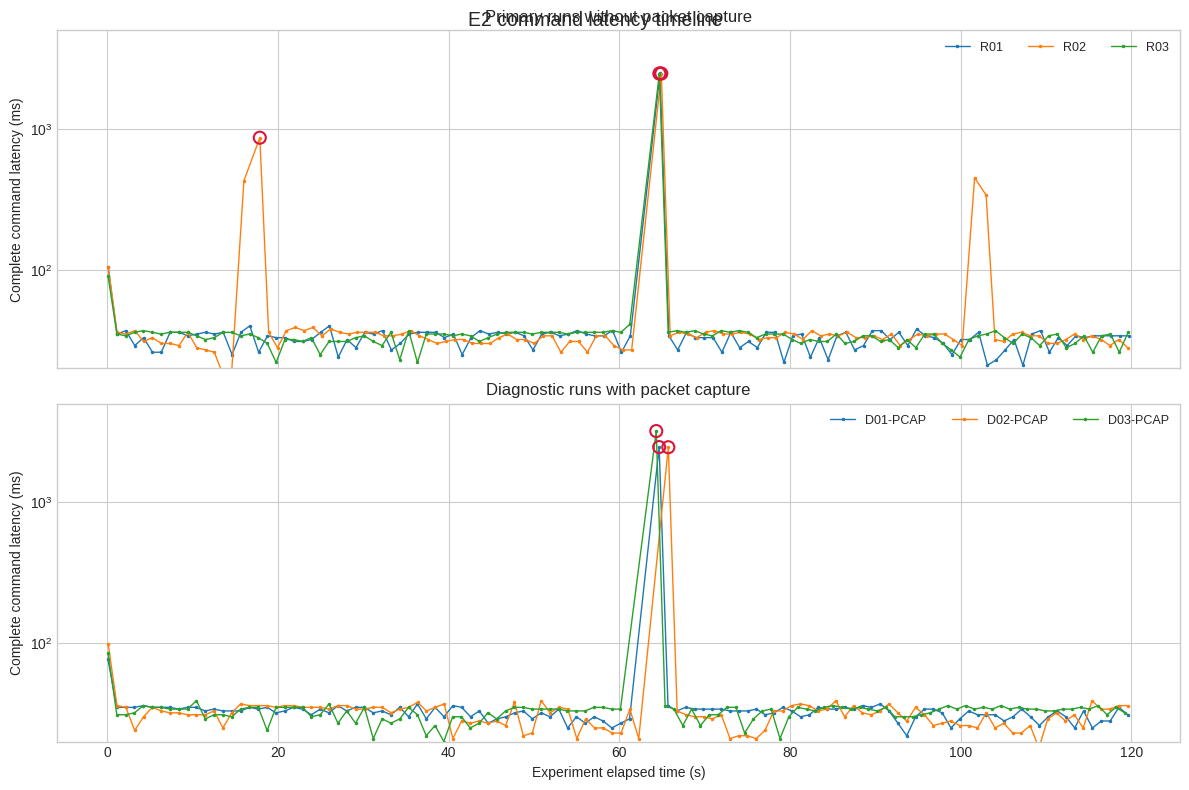

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)
groups = [
    (primary_paths, "Primary runs without packet capture"),
    (diagnostic_paths, "Diagnostic runs with packet capture"),
]
for ax, (paths, title) in zip(axes, groups):
    for path in paths:
        rows = runs[path.stem]
        elapsed = np.array([number(r, "elapsed_ms") / 1000 for r in rows])
        latency = np.array([number(r, "last_command_latency_ms") for r in rows])
        attempts = np.array([number(r, "command_attempt_count", 0) for r in rows])
        label = path.stem.replace("E2-CMD-BASE-", "")
        ax.plot(elapsed, latency, marker=".", markersize=3, linewidth=1, label=label)
        mask = attempts > 1
        ax.scatter(
            elapsed[mask], latency[mask], s=75, facecolors="none",
            edgecolors="crimson", linewidths=1.5, zorder=5
        )
    ax.set_title(title)
    ax.set_ylabel("Complete command latency (ms)")
    ax.set_yscale("log")
    ax.set_ylim(20, 5000)
    ax.legend(ncol=3, loc="upper right")
axes[-1].set_xlabel("Experiment elapsed time (s)")
fig.suptitle("E2 command latency timeline", fontsize=14)
fig.tight_layout()
save_figure(fig, "e2_command_latency_timeline.png")
plt.show()

## Packet-Capture Overhead Check

The plot uses one median and one steady-state p95 per run, preserving the run as the independent unit. Similar values between groups suggest that tcpdump did not materially change ordinary latency. With only three runs per group, this is descriptive rather than a formal equivalence test.

Saved: /home/gabriel/CS-500/results/final_repeated/analysis_images/e2_capture_effect.png


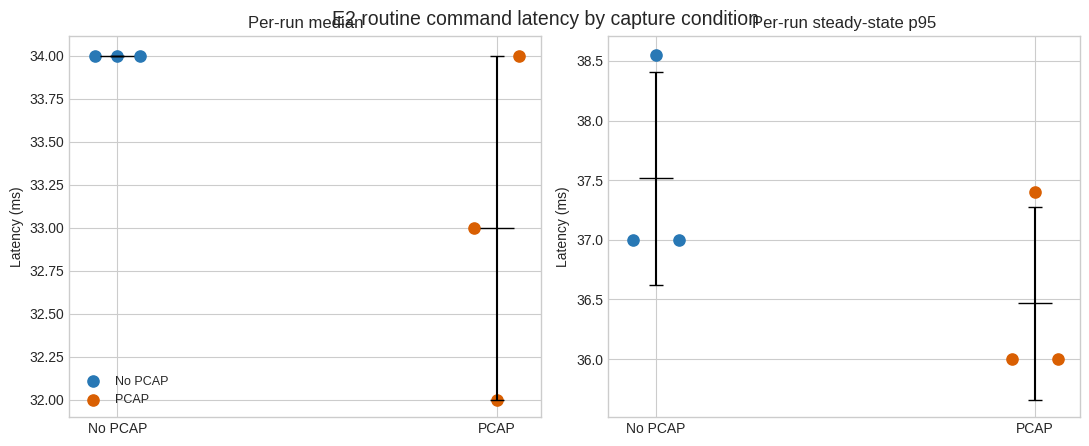

median: no PCAP 34.0 +/- 0.0 ms; PCAP 33.0 +/- 1.0 ms (mean +/- sample SD across runs)
steady p95: no PCAP 37.5 +/- 0.9 ms; PCAP 36.5 +/- 0.8 ms (mean +/- sample SD across runs)


In [39]:
def group_metric(mode, key):
    return [item[key] for item in summaries if item["mode"] == mode]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, key, title in [
    (axes[0], "median_ms", "Per-run median"),
    (axes[1], "steady_p95_ms", "Per-run steady-state p95"),
]:
    for x, mode, color in [
        (0, "No PCAP", "#2878B5"),
        (1, "PCAP", "#D95F02"),
    ]:
        values = group_metric(mode, key)
        offsets = np.linspace(-0.06, 0.06, len(values))
        ax.scatter(
            np.full(len(values), x) + offsets, values,
            s=65, color=color, label=mode if ax is axes[0] else None
        )
        ax.errorbar(
            x, statistics.mean(values), yerr=sample_sd(values),
            fmt="_", markersize=24, color="black", capsize=5
        )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No PCAP", "PCAP"])
    ax.set_ylabel("Latency (ms)")
    ax.set_title(title)
axes[0].legend()
fig.suptitle("E2 routine command latency by capture condition", fontsize=14)
fig.tight_layout()
save_figure(fig, "e2_capture_effect.png")
plt.show()

for key, label in [("median_ms", "median"), ("steady_p95_ms", "steady p95")]:
    a = group_metric("No PCAP", key)
    b = group_metric("PCAP", key)
    print(
        f"{label}: no PCAP {statistics.mean(a):.1f} +/- {sample_sd(a):.1f} ms; "
        f"PCAP {statistics.mean(b):.1f} +/- {sample_sd(b):.1f} ms "
        "(mean +/- sample SD across runs)"
    )

## Internal Timing Of Delayed Commands

For commands above 200 ms, the stacked bars separate accumulated executor receive-wait time, explicit recovery, and remaining client overhead. If receive wait dominates, the CLI delay is not caused by plotting or CSV formatting.

Saved: /home/gabriel/CS-500/results/final_repeated/analysis_images/e2_delayed_command_timing.png


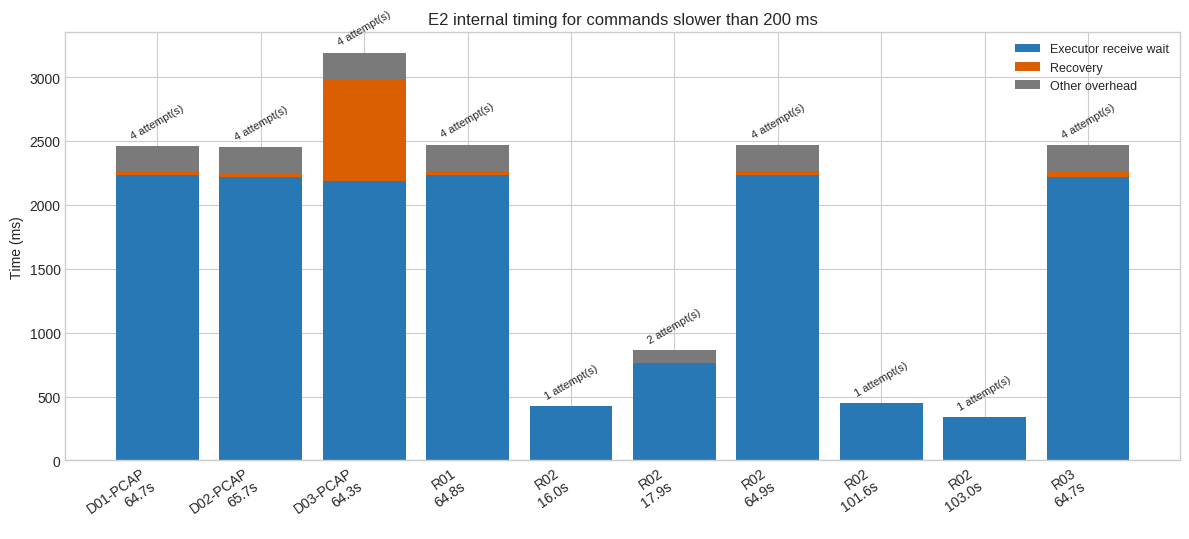

In [40]:
delayed = []
for path in csv_paths:
    for row in runs[path.stem]:
        latency = number(row, "last_command_latency_ms")
        if latency > 200:
            recv_wait = number(row, "command_executor_recv_wait_total_ms", 0)
            recovery = number(row, "command_recovery_ms", 0)
            delayed.append({
                "label": (
                    f"{path.stem.replace('E2-CMD-BASE-', '')}\n"
                    f"{number(row, 'elapsed_ms') / 1000:.1f}s"
                ),
                "latency": latency,
                "recv": recv_wait,
                "recovery": recovery,
                "other": max(0, latency - recv_wait - recovery),
                "attempts": int(number(row, "command_attempt_count", 0)),
            })

x = np.arange(len(delayed))
recv = np.array([d["recv"] for d in delayed])
recovery = np.array([d["recovery"] for d in delayed])
other = np.array([d["other"] for d in delayed])
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.bar(x, recv, label="Executor receive wait", color="#2878B5")
ax.bar(x, recovery, bottom=recv, label="Recovery", color="#D95F02")
ax.bar(x, other, bottom=recv + recovery, label="Other overhead", color="#7A7A7A")
for i, item in enumerate(delayed):
    ax.text(
        i, item["latency"] + 55, f"{item['attempts']} attempt(s)",
        ha="center", fontsize=8, rotation=30
    )
ax.set_xticks(x)
ax.set_xticklabels([d["label"] for d in delayed], rotation=35, ha="right")
ax.set_ylabel("Time (ms)")
ax.set_title("E2 internal timing for commands slower than 200 ms")
ax.legend()
fig.tight_layout()
save_figure(fig, "e2_delayed_command_timing.png")
plt.show()

## Packet-Capture Evidence

These cells invoke tcpdump to read the PCAPs. In E2, outgoing UDP payload length 8 is battery?, length 7 is command, incoming length 2 is ok, and other short incoming payloads are battery values. A request is counted as unanswered when another outgoing request appears before any incoming packet.

The PCAP clock begins at the first captured SDK packet and has a small offset from CSV elapsed time. Correlation therefore uses event order and duration rather than assuming identical zero points.

In [1]:
import struct

def read_udp_ipv4_packets(path):
    data = path.read_bytes()
    magic_formats = {
        b"\xd4\xc3\xb2\xa1": ("<", 1_000_000.0),
        b"\xa1\xb2\xc3\xd4": (">", 1_000_000.0),
        b"\x4d\x3c\xb2\xa1": ("<", 1_000_000_000.0),
        b"\xa1\xb2\x3c\x4d": (">", 1_000_000_000.0),
    }
    if data[:4] not in magic_formats:
        raise ValueError(f"Unsupported PCAP magic in {path}")
    endian, timestamp_scale = magic_formats[data[:4]]
    link_type = struct.unpack(endian + "I", data[20:24])[0]
    offset = 24
    packets = []
    while offset + 16 <= len(data):
        ts_sec, ts_fraction, included_len, _ = struct.unpack(
            endian + "IIII", data[offset:offset + 16]
        )
        offset += 16
        frame = data[offset:offset + included_len]
        offset += included_len

        if link_type == 1 and len(frame) >= 14:  # Ethernet
            network_offset = 14
            ether_type = struct.unpack("!H", frame[12:14])[0]
            if ether_type in (0x8100, 0x88A8) and len(frame) >= 18:
                network_offset = 18
                ether_type = struct.unpack("!H", frame[16:18])[0]
        elif link_type == 276 and len(frame) >= 20:  # Linux cooked v2
            network_offset = 20
            ether_type = struct.unpack("!H", frame[0:2])[0]
        else:
            continue

        if ether_type != 0x0800 or len(frame) < network_offset + 20:
            continue
        ip_packet = frame[network_offset:]
        ip_header_len = (ip_packet[0] & 0x0F) * 4
        if ip_packet[9] != 17 or len(ip_packet) < ip_header_len + 8:
            continue
        udp = ip_packet[ip_header_len:]
        src_port, dst_port, udp_len = struct.unpack("!HHH", udp[:6])
        packets.append({
            "timestamp": ts_sec + ts_fraction / timestamp_scale,
            "src_ip": ".".join(str(value) for value in ip_packet[12:16]),
            "dst_ip": ".".join(str(value) for value in ip_packet[16:20]),
            "src_port": src_port,
            "dst_port": dst_port,
            "length": max(0, udp_len - 8),
        })
    return packets

def read_pcap_packets(path):
    packets = []
    for packet in read_udp_ipv4_packets(path):
        if packet["dst_ip"] == "192.168.10.1" and packet["dst_port"] == 8889:
            direction = "Out"
        elif packet["src_ip"] == "192.168.10.1" and packet["dst_port"] == 8889:
            direction = "In"
        else:
            continue
        packets.append({**packet, "direction": direction})
    if not packets:
        raise ValueError(f"No command-channel packets found in {path}")
    origin = packets[0]["timestamp"]
    for packet in packets:
        packet["elapsed_s"] = packet["timestamp"] - origin
    return packets

def unanswered_bursts(packets):
    bursts = []
    pending = []
    for packet in packets:
        if packet["direction"] == "Out":
            pending.append(packet)
        elif pending:
            if len(pending) > 1:
                bursts.append({
                    "start_s": pending[0]["elapsed_s"],
                    "end_s": packet["elapsed_s"],
                    "duration_s": packet["elapsed_s"] - pending[0]["elapsed_s"],
                    "unanswered": len(pending) - 1,
                })
            pending = []
    return bursts

# Keep the original WSL2 blackout analysis separate. The parser supports both
# Linux cooked v2 and Ethernet PCAP without depending on tcpdump print support.
pcap_paths = sorted(
    p for p in PCAP_DIR.glob("E2-CMD-BASE-*-PCAP.pcap")
    if "-NATIVE-" not in p.name
)
pcap_runs = {path.stem: read_pcap_packets(path) for path in pcap_paths}

header = (
    f"{'PCAP':<14} {'Packets':>8} {'Out':>6} {'In':>6} "
    f"{'Unanswered':>11} {'Start':>9} {'Resumed':>9} {'Window':>9}"
)
print(header)
print("-" * len(header))
for path in pcap_paths:
    packets = pcap_runs[path.stem]
    burst = max(unanswered_bursts(packets), key=lambda b: b["duration_s"])
    outgoing = sum(p["direction"] == "Out" for p in packets)
    incoming = sum(p["direction"] == "In" for p in packets)
    unanswered = sum(b["unanswered"] for b in unanswered_bursts(packets))
    label = path.stem.replace("E2-CMD-BASE-", "")
    print(
        f"{label:<14} {len(packets):>8d} {outgoing:>6d} {incoming:>6d} "
        f"{unanswered:>11d} {burst['start_s']:>8.3f}s "
        f"{burst['end_s']:>8.3f}s {burst['duration_s']:>8.3f}s"
    )

NameError: name 'PCAP_DIR' is not defined

## UDP Events Around Each Blackout

Each subplot shows packets observed by tcpdump. The shaded interval starts with the first request in a sequence lacking an immediate response and ends when incoming traffic resumes. Repeated outgoing battery requests demonstrate that the application continued sending. The later command/ok exchange is SDK recovery.

Saved: /home/gabriel/CS-500/results/final_repeated/analysis_images/e2_pcap_blackout_timeline.png


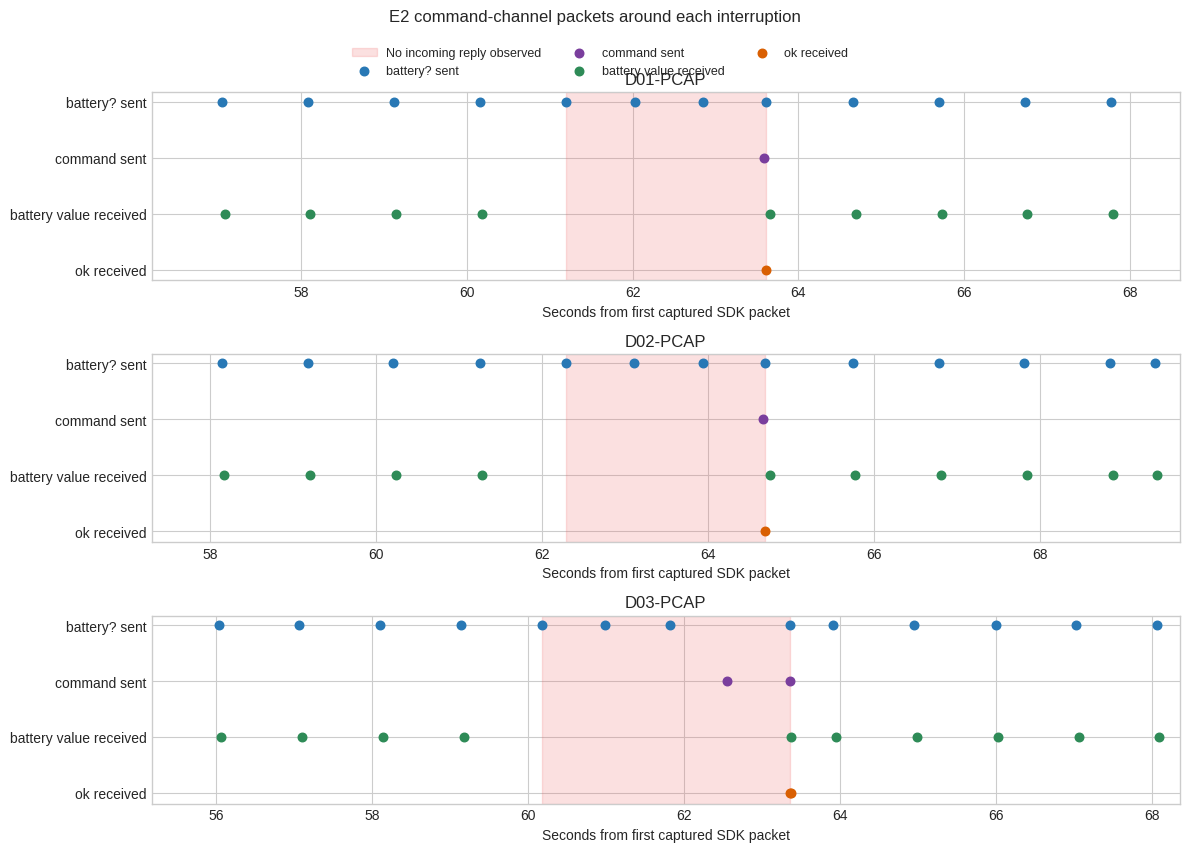

In [42]:
event_y = {
    "battery? sent": 3,
    "command sent": 2,
    "battery value received": 1,
    "ok received": 0,
}
event_color = {
    "battery? sent": "#2878B5",
    "command sent": "#7A3E9D",
    "battery value received": "#2E8B57",
    "ok received": "#D95F02",
}

def packet_event(packet):
    if packet["direction"] == "Out":
        return "battery? sent" if packet["length"] == 8 else "command sent"
    return "ok received" if packet["length"] == 2 else "battery value received"

fig, axes = plt.subplots(len(pcap_paths), 1, figsize=(12, 8))
if len(pcap_paths) == 1:
    axes = [axes]
for ax, path in zip(axes, pcap_paths):
    packets = pcap_runs[path.stem]
    burst = max(unanswered_bursts(packets), key=lambda b: b["duration_s"])
    start, end = max(0, burst["start_s"] - 5), burst["end_s"] + 5
    for event in event_y:
        selected = [
            p for p in packets
            if packet_event(p) == event and start <= p["elapsed_s"] <= end
        ]
        ax.scatter(
            [p["elapsed_s"] for p in selected],
            [event_y[event]] * len(selected),
            s=38, color=event_color[event], label=event, zorder=3
        )
    ax.axvspan(
        burst["start_s"], burst["end_s"],
        color="#EE5858", alpha=0.18, label="No incoming reply observed"
    )
    ax.set_yticks(list(event_y.values()), list(event_y.keys()))
    ax.set_xlim(start, end)
    ax.set_title(path.stem.replace("E2-CMD-BASE-", ""))
    ax.set_xlabel("Seconds from first captured SDK packet")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("E2 command-channel packets around each interruption", y=1.06)
fig.tight_layout()
save_figure(fig, "e2_pcap_blackout_timeline.png")
plt.show()

## Current E2 Interpretation

The next output separates direct observations from inference. Operating-system Wi-Fi logs are still needed to distinguish interface/driver events from radio or drone-side silence.

In [43]:
all_failures = sum(item["failures"] for item in summaries)
all_recoveries = sum(item["recoveries"] for item in summaries)
recovery_times = []
for path in csv_paths:
    recovery_times.extend(
        number(row, "elapsed_ms") / 1000
        for row in runs[path.stem]
        if number(row, "command_attempt_count", 0) > 1
    )
bursts = [
    burst
    for packets in pcap_runs.values()
    for burst in unanswered_bursts(packets)
]
durations = [burst["duration_s"] for burst in bursts]

print("Evidence-supported findings")
print("---------------------------")
print(
    f"1. The six runs contain {all_failures} final failures and "
    f"{all_recoveries} completed recovery events."
)
print(
    "2. Multi-attempt commands completed at: "
    + ", ".join(f"{value:.1f} s" for value in recovery_times)
    + "."
)
print(
    f"3. The PCAPs contain {len(bursts)} request bursts with missing "
    f"immediate replies; windows range from {min(durations):.3f} "
    f"to {max(durations):.3f} s."
)
print(
    "4. Outgoing requests are present at the host interface while "
    "incoming command responses are absent until recovery."
)
print(
    "5. This rules out failure to call the UDP send path as the cause "
    "of the captured timeouts. It does not distinguish drone, radio, "
    "Wi-Fi driver, or host receive loss below the capture point."
)
print(
    "6. Delayed single-attempt responses in uncaptured runs remain "
    "valid latency observations, but CSV alone cannot localize them."
)

Evidence-supported findings
---------------------------
1. The six runs contain 0 final failures and 6 completed recovery events.
2. Multi-attempt commands completed at: 64.7 s, 65.7 s, 64.3 s, 64.8 s, 17.9 s, 64.9 s, 64.7 s.
3. The PCAPs contain 3 request bursts with missing immediate replies; windows range from 2.401 to 3.180 s.
4. Outgoing requests are present at the host interface while incoming command responses are absent until recovery.
5. This rules out failure to call the UDP send path as the cause of the captured timeouts. It does not distinguish drone, radio, Wi-Fi driver, or host receive loss below the capture point.
6. Delayed single-attempt responses in uncaptured runs remain valid latency observations, but CSV alone cannot localize them.


## Recorded Native-Linux Results

All six native runs completed without a final failure, retry, timeout, recovery, or multi-attempt command. Each produced 118 successful `battery?` samples.

| Run | Samples | Duration (s) | Median (ms) | p95 (ms) | Maximum (ms) | Retries | Timeouts | Recoveries | Battery |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| `NATIVE-R01` | 118 | 119.467 | 19 | 21 | 70 | 0 | 0 | 0 | 89 -> 86% |
| `NATIVE-R02` | 118 | 119.437 | 19 | 21 | 85 | 0 | 0 | 0 | 85 -> 83% |
| `NATIVE-R03` | 118 | 119.422 | 19 | 22 | 73 | 0 | 0 | 0 | 82 -> 81% |
| `NATIVE-D01-PCAP` | 118 | 119.413 | 19 | 21 | 62 | 0 | 0 | 0 | 79 -> 77% |
| `NATIVE-D02-PCAP` | 118 | 119.418 | 19 | 21 | 69 | 0 | 0 | 0 | 75 -> 73% |
| `NATIVE-D03-PCAP` | 118 | 119.462 | 19 | 21 | 103 | 0 | 0 | 0 | 72 -> 70% |

No native command exceeded 200 ms. Some per-run maxima occurred in the first sample and included SDK-state assurance; none involved retry or recovery.

Each native PCAP contains one SDK `command` exchange followed by 118 `battery?` exchanges:

| Run | Requests | Responses | Battery RTT median (ms) | Battery RTT p95 (ms) | Battery RTT maximum (ms) | Maximum response gap (ms) |
|---|---:|---:|---:|---:|---:|---:|
| `NATIVE-D01-PCAP` | 119 | 119 | 19.7 | 21.4 | 50.8 | 1025.6 |
| `NATIVE-D02-PCAP` | 119 | 119 | 19.7 | 21.1 | 50.9 | 1023.1 |
| `NATIVE-D03-PCAP` | 119 | 119 | 19.7 | 21.6 | 50.9 | 1023.6 |

There is no missing response, multi-second response gap, or physical-interface evidence of a native blackout. The following code cells recompute these tables from the CSV and PCAP evidence rather than relying only on the recorded values above.

In [44]:
native_run_summaries = [summarize_run(path) for path in native_csv_paths]
header = (
    f"{'Run':<18} {'N':>4} {'Duration':>9} {'OK':>4} {'Fail':>5} "
    f"{'Median':>7} {'p95':>7} {'Max':>7} {'Retry':>6} {'TO':>4} {'Rec':>4} {'Battery':>9}"
)
print(header)
print("-" * len(header))
for path, item in zip(native_csv_paths, native_run_summaries):
    rows = runs[path.stem]
    duration_s = number(rows[-1], "elapsed_ms") / 1000.0
    battery = f"{rows[0]['last_response']}->{rows[-1]['last_response']}"
    print(
        f"{item['run']:<18} {item['samples']:>4d} {duration_s:>8.3f}s "
        f"{item['successes']:>4d} {item['failures']:>5d} "
        f"{item['median_ms']:>7.1f} {item['p95_ms']:>7.1f} {item['max_ms']:>7.1f} "
        f"{item['retries']:>6d} {item['timeouts']:>4d} {item['recoveries']:>4d} {battery:>9}"
    )

Run                   N  Duration   OK  Fail  Median     p95     Max  Retry   TO  Rec   Battery
-----------------------------------------------------------------------------------------------
NATIVE-D01-PCAP     118  119.413s  118     0    19.0    21.0    62.0      0    0    0    79->77
NATIVE-D02-PCAP     118  119.418s  118     0    19.0    21.0    69.0      0    0    0    75->73
NATIVE-D03-PCAP     118  119.462s  118     0    19.0    21.0   103.0      0    0    0    72->70
NATIVE-R01          118  119.467s  118     0    19.0    21.0    70.0      0    0    0    89->86
NATIVE-R02          118  119.437s  118     0    19.0    21.0    85.0      0    0    0    85->83
NATIVE-R03          118  119.422s  118     0    19.0    22.0    73.0      0    0    0    82->81


## WSL2 Versus Native Linux Comparison

The native experiment repeats the same 120-second one-second-interval E2 procedure. Environment and capture condition remain separate factors: three runs are retained in each of four groups (WSL2/no PCAP, WSL2/PCAP, native/no PCAP, and native/PCAP). Values below are computed per run before descriptive group summaries are formed.

Two complementary figures are used. The run-level median/p95 figure compares routine latency. The temporal-contrast figure places all six WSL2 runs and all six matched native runs on identical axes. A 200 ms line separates routine latency from visibly delayed calls.

Condition            Commands  Median mean  Steady p95 mean   Max mean   Retry    TO   Rec
------------------------------------------------------------------------------------------
WSL2 / no PCAP            340        34.00            37.52    2469.67      10    10     3
WSL2 / PCAP               341        33.00            36.47    2701.67       9     9     3
Native / no PCAP          354        19.00            21.33      76.00       0     0     0
Native / PCAP             354        19.00            21.00      78.00       0     0     0
Saved: /home/gabriel/CS-500/results/final_repeated/analysis_images/e2_wsl_vs_native_comparison.png


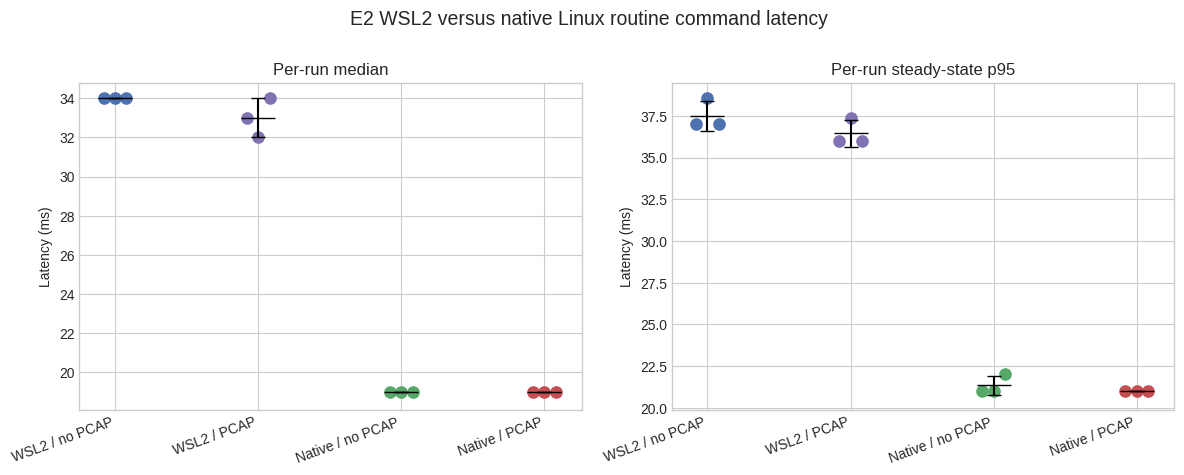

In [45]:
native_summaries = [summarize_run(path) for path in native_csv_paths]
comparison_summaries = summaries + native_summaries

def is_native(item):
    return item["run"].startswith("NATIVE-")

def comparison_group(environment, mode):
    want_native = environment == "Native"
    return [
        item for item in comparison_summaries
        if is_native(item) == want_native and item["mode"] == mode
    ]

comparison_groups = [
    ("WSL2 / no PCAP", comparison_group("WSL2", "No PCAP")),
    ("WSL2 / PCAP", comparison_group("WSL2", "PCAP")),
    ("Native / no PCAP", comparison_group("Native", "No PCAP")),
    ("Native / PCAP", comparison_group("Native", "PCAP")),
]

header = (
    f"{'Condition':<20} {'Commands':>8} {'Median mean':>12} "
    f"{'Steady p95 mean':>16} {'Max mean':>10} {'Retry':>7} {'TO':>5} {'Rec':>5}"
)
print(header)
print("-" * len(header))
for label, items in comparison_groups:
    commands = sum(item["samples"] for item in items)
    median_mean = statistics.mean(item["median_ms"] for item in items)
    steady_mean = statistics.mean(item["steady_p95_ms"] for item in items)
    max_mean = statistics.mean(item["max_ms"] for item in items)
    retries = sum(item["retries"] for item in items)
    timeouts = sum(item["timeouts"] for item in items)
    recoveries = sum(item["recoveries"] for item in items)
    print(
        f"{label:<20} {commands:>8d} {median_mean:>12.2f} "
        f"{steady_mean:>16.2f} {max_mean:>10.2f} "
        f"{retries:>7d} {timeouts:>5d} {recoveries:>5d}"
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
colors = ["#4C72B0", "#8172B2", "#55A868", "#C44E52"]
for ax, key, title in [
    (axes[0], "median_ms", "Per-run median"),
    (axes[1], "steady_p95_ms", "Per-run steady-state p95"),
]:
    for x_pos, ((label, items), color) in enumerate(zip(comparison_groups, colors)):
        values = [item[key] for item in items]
        offsets = np.linspace(-0.08, 0.08, len(values))
        ax.scatter(np.full(len(values), x_pos) + offsets, values, s=65, color=color)
        ax.errorbar(
            x_pos, statistics.mean(values), yerr=sample_sd(values),
            fmt="_", markersize=24, color="black", capsize=5
        )
    ax.set_xticks(range(len(comparison_groups)), [g[0] for g in comparison_groups], rotation=20, ha="right")
    ax.set_ylabel("Latency (ms)")
    ax.set_title(title)
fig.suptitle("E2 WSL2 versus native Linux routine command latency", fontsize=14, y=0.98)
fig.tight_layout(rect=(0, 0, 1, 0.90))
save_figure(fig, "e2_wsl_vs_native_comparison.png")
plt.show()

# Direct temporal contrast between the matched WSL2 and native campaigns.
def plot_latency_runs(ax, paths, title, annotate_summary=None):
    delayed_points = []
    for path in paths:
        rows = runs[path.stem]
        elapsed = np.asarray([number(r, "elapsed_ms") / 1000 for r in rows])
        latency = np.asarray([number(r, "last_command_latency_ms") for r in rows])
        label = path.stem.replace("E2-CMD-BASE-", "")
        ax.plot(elapsed, latency, marker=".", markersize=2.8, linewidth=.8, alpha=.82, label=label)
        mask = latency > 200
        delayed_points.extend(zip(elapsed[mask], latency[mask]))
        ax.scatter(elapsed[mask], latency[mask], s=58, facecolors="none", edgecolors="crimson", linewidths=1.3, zorder=6)
    ax.set_title(title)
    ax.set_yscale("log")
    ax.set_ylim(10, 5000)
    ax.set_xlim(0, 125)
    ax.axhline(200, color="crimson", linestyle=":", linewidth=1, label="200 ms threshold")
    ax.axvline(60, color="#555555", linestyle="--", linewidth=.9)
    ax.axvline(120, color="#555555", linestyle="--", linewidth=.9)
    if annotate_summary:
        ax.text(.015, .95, annotate_summary(delayed_points), transform=ax.transAxes, va="top", fontsize=9, bbox=dict(facecolor="white", alpha=.88, edgecolor="#BBBBBB"))
    ax.legend(ncol=1, fontsize=7, loc="center left", bbox_to_anchor=(1.005, .5), borderaxespad=0)

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True, sharey=True)
plot_latency_runs(axes[0], wsl_csv_paths, "WSL2 — recovered delays cluster at 64.3–65.7 s", lambda points: f"{sum(t > 50 and t < 75 for t, _ in points)}/6 runs delayed in the recurring window")
plot_latency_runs(axes[1], native_csv_paths, "Native Linux — no corresponding recurring delay", lambda points: f"{len(points)}/708 samples above 200 ms")
for ax in axes:
    ax.set_ylabel("Command latency (ms, log)")
axes[1].set_xlabel("Experiment elapsed time (s)")
fig.suptitle("E2 temporal evidence: WSL2 recurring delay disappears on native Linux", fontsize=14, y=1.01)
fig.tight_layout(rect=(0, 0, .84, 1))
save_figure(fig, "e2_wsl_native_temporal_contrast.png")
plt.show()

### Temporal Contrast of the WSL2 Delay

![E2 WSL2 and native temporal contrast](final_repeated/analysis_images/e2_wsl_native_temporal_contrast.png)

The upper panel shows the WSL2 campaign: all six runs contain a recovered multi-second command near 64.3-65.7 seconds. The lower panel shows the matched native campaign on the same axes: none of 708 commands exceeded 200 ms and no event appears in the recurring window.

### Native Physical-Interface PCAP Validation

The native EN10MB captures do not contain the cooked-capture `Out`/`In` marker used by the WSL2 parser. Direction is therefore selected explicitly from IPv4 addresses and destination ports. This also excludes Tello telemetry that may use source port 8889 while targeting host port 8890. Because the command API is synchronous, the nth outgoing command-channel packet pairs with the nth incoming command-channel response. The first pair is SDK `command`/`ok`; the remaining 118 pairs are `battery?` exchanges.

In [46]:
def read_filtered_timestamps(path, filter_expression):
    tcpdump = shutil.which("tcpdump")
    if not tcpdump:
        raise RuntimeError("tcpdump is required for the PCAP analysis.")
    result = subprocess.run(
        [tcpdump, "-nn", "-tt", "-r", str(path), filter_expression],
        check=True, capture_output=True, text=True
    )
    return [
        float(line.split()[0])
        for line in result.stdout.splitlines()
        if line.strip()
    ]

native_pcap_paths = sorted(PCAP_DIR.glob("E2-CMD-BASE-NATIVE-D*-PCAP.pcap"))
header = (
    f"{'PCAP':<20} {'Out':>5} {'In':>5} {'RTT med':>9} "
    f"{'RTT p95':>9} {'RTT max':>9} {'Max in gap':>11}"
)
print(header)
print("-" * len(header))
for path in native_pcap_paths:
    outgoing = read_filtered_timestamps(
        path, "dst host 192.168.10.1 and dst port 8889"
    )
    incoming = read_filtered_timestamps(
        path, "src host 192.168.10.1 and dst port 8889"
    )
    if len(outgoing) != len(incoming):
        raise RuntimeError(
            f"Unmatched command packets in {path.name}: "
            f"{len(outgoing)} outgoing, {len(incoming)} incoming"
        )
    paired_rtt_ms = np.array([
        (response - request) * 1000.0
        for request, response in zip(outgoing, incoming)
    ])
    battery_rtt_ms = paired_rtt_ms[1:]
    incoming_gaps_ms = np.diff(np.asarray(incoming)) * 1000.0
    label = path.stem.replace("E2-CMD-BASE-", "")
    print(
        f"{label:<20} {len(outgoing):>5d} {len(incoming):>5d} "
        f"{np.median(battery_rtt_ms):>9.1f} "
        f"{np.percentile(battery_rtt_ms, 95):>9.1f} "
        f"{np.max(battery_rtt_ms):>9.1f} {np.max(incoming_gaps_ms):>11.1f}"
    )

PCAP                   Out    In   RTT med   RTT p95   RTT max  Max in gap
--------------------------------------------------------------------------
NATIVE-D01-PCAP        119   119      19.7      21.4      50.8      1025.6
NATIVE-D02-PCAP        119   119      19.7      21.1      50.9      1023.1
NATIVE-D03-PCAP        119   119      19.7      21.6      50.9      1023.6


### Comparison Interpretation

**Direct observations:** all 708 native command samples completed successfully; no native run contained a retry, timeout, recovery, multi-attempt command, or interruption near 60-66 seconds. Each physical-interface PCAP contains 119 outgoing command-channel packets and 119 matching responses. Native per-run medians were 19 ms and steady p95 values were 21-22 ms, compared with approximately 32-34 ms and 36-38.5 ms in WSL2. Capture did not materially alter the native routine latency.

**Inference:** disappearance across all six native runs is strong evidence that the WSL2/Windows path, or another condition removed or changed with that environment, contributed to the original periodic blackout. It substantially reduces the likelihood of a deterministic defect in the shared C++ command implementation or a deterministic approximately 60-second Tello behavior. It does not identify the exact WSL2, Hyper-V, Windows firewall, Wi-Fi management, or driver component, and it does not exclude intermittent radio or drone-side loss in other sessions.

### Investigation Questions And Answers

1. **Does a recovered multi-attempt event still occur in every native run?** No. None of the six native runs contains one.
2. **Does it still occur around 60-66 seconds?** No. No native interruption occurs there or elsewhere in the 120-second runs.
3. **Is native routine latency similar to WSL2?** No. Native per-run medians are 19 ms and steady p95 values are 21-22 ms, lower than the WSL2 values.
4. **During a native captured interruption, are outgoing requests visible?** Not applicable because no native captured interruption occurred; all expected outgoing requests are visible.
5. **Are incoming responses absent from the physical-interface capture?** No. Every captured request has a corresponding incoming command response.
6. **Do interface counters report errors at the same time?** Not measured continuously; optional counter logs were not collected.
7. **Do kernel or NetworkManager logs show scans, reconnects, power management, firmware, or driver events?** Not measured continuously during E2.
8. **Does packet capture alter routine latency on native Linux?** No material effect is observed: native captured and uncaptured groups both have 19 ms per-run medians and nearly identical steady p95 values.

### Interpretation Matrix For Future Reproductions

| Observation | Supported interpretation |
|---|---|
| Blackout disappears on native Linux | WSL2/Windows path or another environment-linked condition contributed; deterministic API/drone timer becomes less likely |
| Blackout remains at the same time | WSL2 becomes less likely; investigate adapter driver/firmware, scanning, power management, radio, drone, or a periodic API mechanism |
| API CSV records a send attempt but physical-interface PCAP lacks the request | Investigate application send path, process scheduling, socket behavior, or native network stack |
| Physical PCAP contains outgoing requests but no responses | Failure lies below/beyond API send: driver receive path, radio link, or drone silence |
| Physical PCAP contains timely responses but API reports timeout | Direct evidence to investigate command socket ownership, receive synchronization, parsing, or executor behavior |
| Capture and no-capture routine latency differ | Treat capture as an experimental factor; do not pool the conditions |

The current native result follows the first row: the blackout disappeared in all six runs.

## E2 Conclusion And Limitations

The native E2 reproduction phase is complete. All 708 native command samples succeeded with zero retries, timeouts, or recoveries, while every WSL2 run contained a recovered periodic interruption. The native physical-interface PCAPs show complete request/response sequences. This strongly implicates the removed WSL2/Windows path or another environment-linked condition, while substantially reducing the likelihood of a deterministic defect in the shared C++ command code or an approximately 60-second Tello timer.

This descriptive comparison has three runs per condition and was not randomized across operating systems. It cannot name one exact WSL2, Hyper-V, firewall, Wi-Fi-management, or driver component. Exact Windows-side localization would require synchronized Windows WLAN, firewall, driver, interface-event, and physical-adapter capture evidence.

## E3 Telemetry Baseline: WSL2 Versus Native Linux

E3 repeats the 150-second telemetry-only baseline three times on native Linux and compares it with the existing WSL2 primary and diagnostic groups. The drone remained stationary; the native identifiers are `E3-STATE-CLI-NATIVE-R01` through `R03`.

Before the native series, two smoke queries and a short state check failed even though association, route, signal, and ping were healthy. Power-cycling the drone restored SDK entry and telemetry. These attempts are a session-gate transient, not E3 repetitions, and no experimental CSV was retained for them.

The PCAP trigger was intentionally conditional: because none of the three native CSVs reported a gap, stale interval, invalid packet, timeout, or receiver error, no native E3 PCAP run was added. The earlier WSL2 PCAP group remains separate from the uncaptured primary data.

Per-run E3 summaries
Condition / run                Packets  Hz med   Age med/p95    IA med/p95/max  Gaps 300/500/1000     OK/DEG/STALE %
--------------------------------------------------------------------------------------------------------------------
WSL2 / no PCAP / R01              1463    9.72  47.0/95.6   103.0/104.0/155      0/0   /0    100.0/0.0  /0.0  
WSL2 / no PCAP / R02              1463    9.71  51.0/99.2   103.0/105.0/156      0/0   /0    100.0/0.0  /0.0  
WSL2 / no PCAP / R03              1466    9.77  49.0/98.6   103.0/104.0/156      0/0   /0    100.0/0.0  /0.0  
WSL2 / PCAP / D01-PCAP            1464    9.74  49.0/96.2   103.0/105.0/155      0/0   /0    100.0/0.0  /0.0  
WSL2 / PCAP / D02-PCAP            1467    9.74  51.0/98.2   103.0/104.0/156      0/0   /0    100.0/0.0  /0.0  
WSL2 / PCAP / D03-PCAP            1471    9.79  51.0/100.6  103.0/104.0/157      0/0   /0    100.0/0.0  /0.0  
Native / no PCAP / NATIVE-R01     1483    9.88  50.0/95.0   101.0/103.6/155    

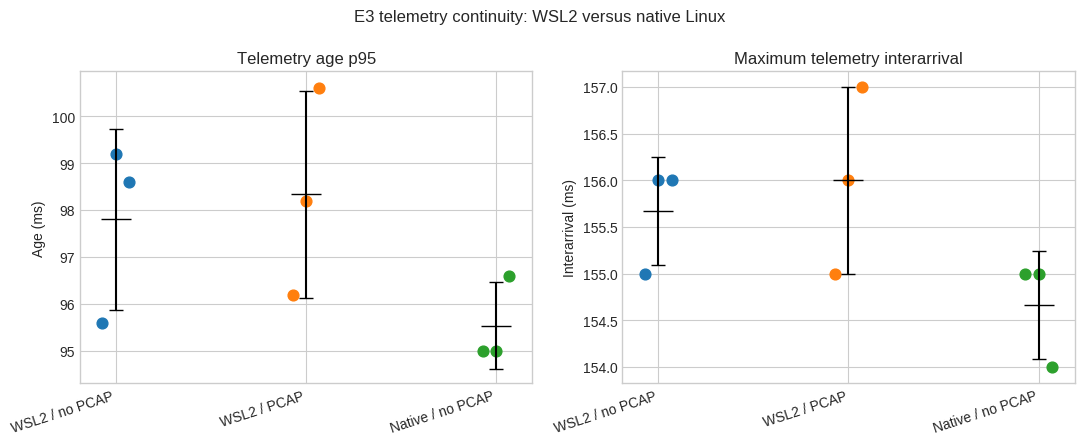

In [47]:
def finite_column(rows, key, exclude_negative=True):
    values = [number(row, key) for row in rows]
    values = [value for value in values if math.isfinite(value)]
    if exclude_negative:
        values = [value for value in values if value >= 0]
    return values

def summarize_e3(path):
    rows = read_csv_rows(path)
    age = finite_column(rows, "telemetry_age_ms")
    interarrival = finite_column(rows, "telemetry_interarrival_ms")
    hz = finite_column(rows, "telemetry_hz_ema")
    quality_counts = {
        label: sum(row.get("telemetry_quality") == label for row in rows)
        for label in ("OK", "DEGRADED", "STALE")
    }
    row_count = sum(quality_counts.values())
    return {
        "run": path.stem.replace("E3-STATE-CLI-", ""),
        "packets": int(number(rows[-1], "telemetry_packets_total", 0)),
        "valid": int(number(rows[-1], "telemetry_packets_valid", 0)),
        "invalid": int(number(rows[-1], "telemetry_packets_invalid", 0)),
        "timeouts": int(number(rows[-1], "telemetry_timeouts", 0)),
        "errors": int(number(rows[-1], "telemetry_errors", 0)),
        "hz_median": float(np.median(hz)),
        "age_median": float(np.median(age)),
        "age_p95": percentile(age, 95),
        "age_max": float(np.max(age)),
        "interarrival_median": float(np.median(interarrival)),
        "interarrival_p95": percentile(interarrival, 95),
        "interarrival_max": number(rows[-1], "telemetry_max_interarrival_ms"),
        "gap300": int(number(rows[-1], "telemetry_gap_events_300ms", 0)),
        "gap500": int(number(rows[-1], "telemetry_gap_events_500ms", 0)),
        "gap1000": int(number(rows[-1], "telemetry_gap_events_1000ms", 0)),
        "ok_pct": 100.0 * quality_counts["OK"] / row_count,
        "degraded_pct": 100.0 * quality_counts["DEGRADED"] / row_count,
        "stale_pct": 100.0 * quality_counts["STALE"] / row_count,
    }

e3_groups = [
    ("WSL2 / no PCAP", sorted(DATA_DIR.glob("E3-STATE-CLI-R*.csv"))),
    ("WSL2 / PCAP", sorted(DATA_DIR.glob("E3-STATE-CLI-D*-PCAP.csv"))),
    ("Native / no PCAP", sorted(DATA_DIR.glob("E3-STATE-CLI-NATIVE-R*.csv"))),
]
e3_summaries = [
    (label, [summarize_e3(path) for path in paths])
    for label, paths in e3_groups
]

print("Per-run E3 summaries")
header = (
    f"{'Condition / run':<30} {'Packets':>7} {'Hz med':>7} "
    f"{'Age med/p95':>13} {'IA med/p95/max':>17} "
    f"{'Gaps 300/500/1000':>18} {'OK/DEG/STALE %':>18}"
)
print(header)
print("-" * len(header))
for label, items in e3_summaries:
    for item in items:
        print(
            f"{(label + ' / ' + item['run']):<30} {item['packets']:>7d} "
            f"{item['hz_median']:>7.2f} "
            f"{item['age_median']:>5.1f}/{item['age_p95']:<6.1f} "
            f"{item['interarrival_median']:>5.1f}/{item['interarrival_p95']:<5.1f}/{item['interarrival_max']:<5.0f} "
            f"{item['gap300']:>4d}/{item['gap500']:<4d}/{item['gap1000']:<4d} "
            f"{item['ok_pct']:>5.1f}/{item['degraded_pct']:<5.1f}/{item['stale_pct']:<5.1f}"
        )

print("\nAcross-run mean and sample SD")
for label, items in e3_summaries:
    print(f"\n{label}")
    for key in (
        "hz_median", "age_median", "age_p95", "age_max",
        "interarrival_median", "interarrival_p95", "interarrival_max"
    ):
        values = [item[key] for item in items]
        print(
            f"  {key:<22} mean={statistics.mean(values):8.3f} "
            f"sd={sample_sd(values):7.3f}"
        )
    print(
        "  totals: "
        f"invalid={sum(item['invalid'] for item in items)}, "
        f"timeouts={sum(item['timeouts'] for item in items)}, "
        f"errors={sum(item['errors'] for item in items)}, "
        f"gaps300/500/1000="
        f"{sum(item['gap300'] for item in items)}/"
        f"{sum(item['gap500'] for item in items)}/"
        f"{sum(item['gap1000'] for item in items)}"
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, key, title, ylabel in [
    (axes[0], "age_p95", "Telemetry age p95", "Age (ms)"),
    (axes[1], "interarrival_max", "Maximum telemetry interarrival", "Interarrival (ms)"),
]:
    for pos, (label, items) in enumerate(e3_summaries):
        values = [item[key] for item in items]
        ax.scatter(
            np.full(len(values), pos) + np.linspace(-0.07, 0.07, len(values)),
            values,
            s=60,
        )
        ax.errorbar(
            pos, statistics.mean(values), yerr=sample_sd(values),
            fmt="_", color="black", markersize=22, capsize=5
        )
    ax.set_xticks(range(len(e3_summaries)))
    ax.set_xticklabels(
        [label for label, _ in e3_summaries], rotation=18, ha="right"
    )
    ax.set_title(title)
    ax.set_ylabel(ylabel)
fig.suptitle("E3 telemetry continuity: WSL2 versus native Linux")
fig.tight_layout(rect=(0, 0, 1, 0.92))
save_figure(fig, "e3_wsl_vs_native_telemetry.png")
plt.show()

### E3 Interpretation

All three native runs received only valid telemetry packets, with no invalid packets, timeouts, receiver errors, gap events >=300/500/1000 ms, or non-`OK` rows. The native group collected 4,450 packets. Its mean of per-run median rates was 9.88 Hz; mean median age was 50.67 ms, mean p95 age 95.53 ms, mean p95 interarrival 103.73 ms, and mean maximum interarrival 154.67 ms.

The WSL2 primary group likewise had zero gaps and non-`OK` rows, with corresponding values 9.74 Hz, 49.00 ms, 97.80 ms, 104.33 ms, and 155.67 ms. The small differences favor neither a materially different telemetry process nor a native regression; native is equivalent or slightly better in upper-tail age. E3 therefore reinforces E2: the reason to leave WSL2 is the command blackout evidence, while telemetry continuity remains healthy on native Linux.

## E4 Native FFmpeg Video Baseline

E4 measures FFmpeg transport and decoding together with telemetry while excluding Qt, plotting, and GUI event-loop work. Three independent native-Linux primary runs were recorded for 150 seconds without PCAP as `E4-VIDEO-CLI-NATIVE-R01` through `R03`. The drone remained stationary and the camera scene, host, adapter, build, and one-second sampling interval were held constant.

The analysis reports both the decoder FPS EMA and frame-count throughput, frame freshness and continuity labels, decoded frames and errors, dimensions and keyframes, telemetry behavior under video load, recovery events, and battery conditions. Per-run summaries are calculated before the across-run mean and sample standard deviation.

Per-run E4 summaries
Run     Frames/KF   FPS EMA med/p95  FPS count med/min   Age med/p95/max  Quality OK/D/S Err acq/final   Battery
----------------------------------------------------------------------------------------------------------------
R01    4477/150    29.998/30.025    30.00/28.00     13/27.0 /29      148/0  /0       0/0      90->85 
R02    4493/150    29.999/31.231    30.00/28.41     17/32.0 /38      148/0  /0      15/15     77->73 
R03    4503/151    29.994/30.030    30.00/28.33     17/29.6 /38      149/0  /0       1/1      82->80 

Telemetry under E4 video load
Run    Age med/p95    IA med/p95/max  Gaps 300/500/1000 Recoveries
------------------------------------------------------------------
R01   47.0/97.2   101.0/104.0/158      0/0   /0             0
R02   51.0/91.6   101.0/105.0/156      0/0   /0             0
R03   52.0/91.0   101.0/105.0/155      0/0   /0             0

Across-run mean and sample SD
frames                         mean= 4491.000 sd=  13.115
keyfram

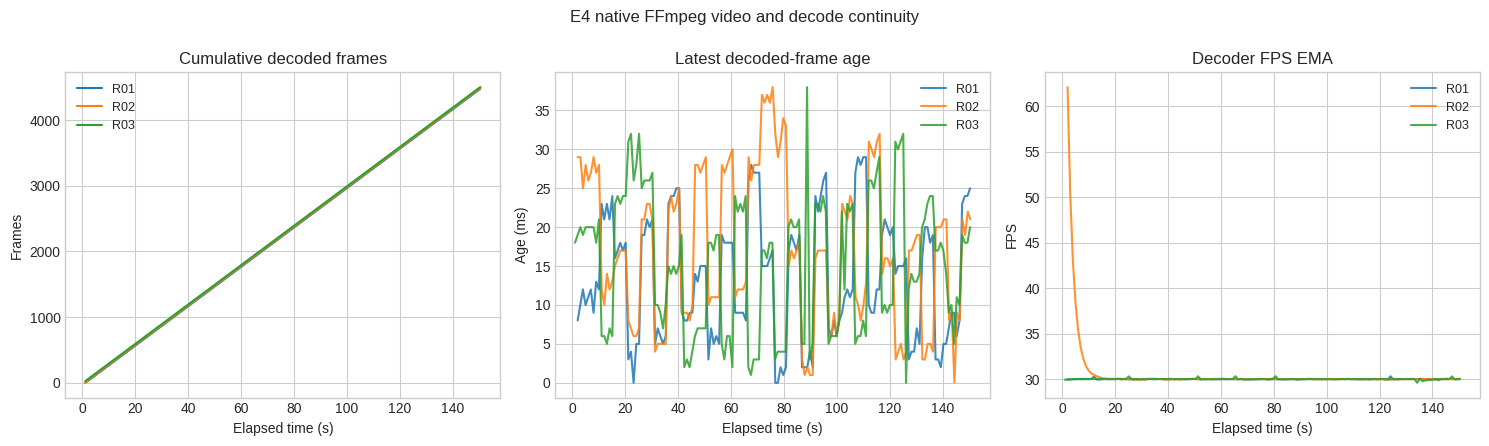

In [48]:
def summarize_e4(path):
    rows = read_csv_rows(path)
    elapsed = np.asarray(finite_column(rows, "elapsed_ms"), dtype=float)
    frames = np.asarray(finite_column(rows, "decoder_frames_decoded"), dtype=float)
    effective_fps = 1000.0 * np.diff(frames) / np.diff(elapsed)
    decoder_fps = [
        value for value in finite_column(rows, "decoder_fps_ema")
        if value > 0
    ]
    video_age = finite_column(rows, "video_age_ms")
    telemetry_age = finite_column(rows, "telemetry_age_ms")
    telemetry_interarrival = finite_column(rows, "telemetry_interarrival_ms")
    acquisition_index = next(
        i for i, row in enumerate(rows)
        if number(row, "decoder_frames_decoded", 0) > 0
    )
    errors_at_acquisition = int(
        number(rows[acquisition_index], "decoder_errors", 0)
    )
    errors_final = int(number(rows[-1], "decoder_errors", 0))
    video_quality = {
        label: sum(row.get("video_quality") == label for row in rows)
        for label in ("OK", "DEGRADED", "STALE", "NO_DATA")
    }
    return {
        "run": path.stem.replace("E4-VIDEO-CLI-NATIVE-", ""),
        "rows": len(rows),
        "duration_s": elapsed[-1] / 1000.0,
        "frames": int(frames[-1]),
        "keyframes": int(number(rows[-1], "keyframes", 0)),
        "frame_width": int(number(rows[-1], "frame_width", 0)),
        "frame_height": int(number(rows[-1], "frame_height", 0)),
        "decoder_fps_median": float(np.median(decoder_fps)),
        "decoder_fps_p95": percentile(decoder_fps, 95),
        "decoder_fps_min": float(np.min(decoder_fps)),
        "decoder_fps_max": float(np.max(decoder_fps)),
        "effective_fps_median": float(np.median(effective_fps)),
        "effective_fps_p05": percentile(effective_fps, 5),
        "effective_fps_min": float(np.min(effective_fps)),
        "age_median": float(np.median(video_age)),
        "age_p95": percentile(video_age, 95),
        "age_max": float(np.max(video_age)),
        "ok_rows": video_quality["OK"],
        "degraded_rows": video_quality["DEGRADED"],
        "stale_rows": video_quality["STALE"],
        "no_data_rows": video_quality["NO_DATA"],
        "errors_at_acquisition": errors_at_acquisition,
        "errors_final": errors_final,
        "errors_after_acquisition": errors_final - errors_at_acquisition,
        "telemetry_age_median": float(np.median(telemetry_age)),
        "telemetry_age_p95": percentile(telemetry_age, 95),
        "telemetry_interarrival_median": float(np.median(telemetry_interarrival)),
        "telemetry_interarrival_p95": percentile(telemetry_interarrival, 95),
        "telemetry_interarrival_max": number(
            rows[-1], "telemetry_max_interarrival_ms"
        ),
        "telemetry_gap300": int(
            number(rows[-1], "telemetry_gap_events_300ms", 0)
        ),
        "telemetry_gap500": int(
            number(rows[-1], "telemetry_gap_events_500ms", 0)
        ),
        "telemetry_gap1000": int(
            number(rows[-1], "telemetry_gap_events_1000ms", 0)
        ),
        "recoveries": sum(
            row.get("recovery_attempted") == "1" for row in rows
        ),
        "battery_first": int(finite_column(rows, "telemetry_bat")[0]),
        "battery_final": int(finite_column(rows, "telemetry_bat")[-1]),
    }

e4_paths = sorted(DATA_DIR.glob("E4-VIDEO-CLI-NATIVE-R*.csv"))
e4 = [summarize_e4(path) for path in e4_paths]

print("Per-run E4 summaries")
header = (
    f"{'Run':<4} {'Frames/KF':>12} {'FPS EMA med/p95':>17} "
    f"{'FPS count med/min':>18} {'Age med/p95/max':>17} "
    f"{'Quality OK/D/S':>15} {'Err acq/final':>13} {'Battery':>9}"
)
print(header)
print("-" * len(header))
for item in e4:
    print(
        f"{item['run']:<4} "
        f"{item['frames']:>6d}/{item['keyframes']:<5d} "
        f"{item['decoder_fps_median']:>7.3f}/{item['decoder_fps_p95']:<7.3f} "
        f"{item['effective_fps_median']:>7.2f}/{item['effective_fps_min']:<7.2f} "
        f"{item['age_median']:>4.0f}/{item['age_p95']:<5.1f}/{item['age_max']:<5.0f} "
        f"{item['ok_rows']:>5d}/{item['degraded_rows']:<3d}/{item['stale_rows']:<3d} "
        f"{item['errors_at_acquisition']:>5d}/{item['errors_final']:<5d} "
        f"{item['battery_first']:>3d}->{item['battery_final']:<3d}"
    )

print("\nTelemetry under E4 video load")
header = (
    f"{'Run':<4} {'Age med/p95':>13} {'IA med/p95/max':>17} "
    f"{'Gaps 300/500/1000':>18} {'Recoveries':>10}"
)
print(header)
print("-" * len(header))
for item in e4:
    print(
        f"{item['run']:<4} "
        f"{item['telemetry_age_median']:>5.1f}/{item['telemetry_age_p95']:<6.1f} "
        f"{item['telemetry_interarrival_median']:>5.1f}/"
        f"{item['telemetry_interarrival_p95']:<5.1f}/"
        f"{item['telemetry_interarrival_max']:<5.0f} "
        f"{item['telemetry_gap300']:>4d}/{item['telemetry_gap500']:<4d}/"
        f"{item['telemetry_gap1000']:<4d} {item['recoveries']:>10d}"
    )

print("\nAcross-run mean and sample SD")
for key in (
    "frames", "keyframes", "decoder_fps_median", "decoder_fps_p95",
    "effective_fps_median", "effective_fps_min", "age_median",
    "age_p95", "age_max", "telemetry_age_median",
    "telemetry_age_p95", "telemetry_interarrival_median",
    "telemetry_interarrival_p95", "telemetry_interarrival_max",
):
    values = [item[key] for item in e4]
    print(
        f"{key:<30} mean={statistics.mean(values):9.3f} "
        f"sd={sample_sd(values):8.3f}"
    )

print("\nNon-OK video rows")
for path in e4_paths:
    for row in read_csv_rows(path):
        if row.get("video_quality") in ("DEGRADED", "STALE"):
            print(
                f"{path.stem}: elapsed={number(row, 'elapsed_ms') / 1000:.3f}s, "
                f"quality={row['video_quality']}, "
                f"frame_age={number(row, 'video_age_ms'):.0f}ms, "
                f"frames={number(row, 'decoder_frames_decoded'):.0f}, "
                f"packets={number(row, 'video_packets_total'):.0f}"
            )

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for item in e4:
    rows = read_csv_rows(
        DATA_DIR / f"E4-VIDEO-CLI-NATIVE-{item['run']}.csv"
    )
    elapsed_s = np.asarray(finite_column(rows, "elapsed_ms")) / 1000.0
    axes[0].plot(
        elapsed_s, finite_column(rows, "decoder_frames_decoded"),
        label=item["run"]
    )
    video_points = [
        (number(row, "elapsed_ms") / 1000.0, number(row, "video_age_ms"))
        for row in rows if number(row, "video_age_ms") >= 0
    ]
    axes[1].plot(
        [point[0] for point in video_points],
        [point[1] for point in video_points],
        label=item["run"], alpha=0.85
    )
    fps_points = [
        (number(row, "elapsed_ms") / 1000.0, number(row, "decoder_fps_ema"))
        for row in rows if number(row, "decoder_fps_ema") > 0
    ]
    axes[2].plot(
        [point[0] for point in fps_points],
        [point[1] for point in fps_points],
        label=item["run"], alpha=0.85
    )
axes[0].set(
    title="Cumulative decoded frames",
    xlabel="Elapsed time (s)", ylabel="Frames"
)
axes[1].set(
    title="Latest decoded-frame age",
    xlabel="Elapsed time (s)", ylabel="Age (ms)"
)
axes[2].set(
    title="Decoder FPS EMA",
    xlabel="Elapsed time (s)", ylabel="FPS"
)
for ax in axes:
    ax.legend()
fig.suptitle("E4 native FFmpeg video and decode continuity")
fig.tight_layout(rect=(0, 0, 1, 0.92))
save_figure(fig, "e4_native_video_continuity.png")
plt.show()

### E4 Results

All three primary runs completed at 960x720 and maintained a median decoder rate of approximately 30 fps. R01 recorded 4,477 frames and 150 keyframes; R02 recorded 4,493 frames and 150 keyframes; R03 recorded 4,503 frames and 151 keyframes. Across runs, frame count averaged 4,491.0 (SD 13.12), keyframes averaged 150.33 (SD 0.58), and the per-run decoder-FPS median averaged 29.997 fps (SD 0.002). Frame-age median averaged 15.67 ms (SD 2.31), p95 averaged 29.53 ms (SD 2.50), and maximum averaged 35.0 ms (SD 5.20).

All classified video rows were `OK`; there were no `DEGRADED` or `STALE` rows. Decoder errors were confined to stream acquisition (0, 15, and 1 respectively) and did not increase afterward. No recovery action was invoked.

Telemetry also remained continuous under video load. Across runs, telemetry-age median averaged 50.0 ms, p95 averaged 93.27 ms, interarrival median averaged 101.0 ms, interarrival p95 averaged 104.67 ms, and maximum interarrival averaged 156.33 ms. There were no telemetry gaps at 300, 500, or 1000 ms. No E4 PCAP was required.

## E2-E4 Metric Coverage

The notebook incorporates every primary metric specified by the protocol for E2 through E4. Each statistical summary is first calculated per run; group values are the mean and sample standard deviation of those independent run summaries.

| Experiment | Protocol metrics incorporated in this notebook | Evidence fields or analysis |
|---|---|---|
| E2 command baseline | command median, p95 and maximum latency; final failures; retries and timeouts; recovered transient losses; receive-wait, executor and recovery timing | `last_command_latency_ms`, command result/count fields, internal attempt logs, timing diagnostics, and matched command-channel PCAP |
| E3 telemetry baseline | receive-rate EMA; age median/p95/maximum; interarrival median/p95/maximum; gaps at 300/500/1000 ms; percentages `OK`/`DEGRADED`/`STALE`; invalid packets, timeouts and receiver errors | `telemetry_hz_ema`, age/interarrival fields, cumulative gap counters, quality labels, and receiver counters |
| E4 video baseline | decoder FPS median and variation; frame age and continuity labels; decoded frames and errors; dimensions and keyframe count; telemetry age/interarrival and gaps under video load; recovery events; battery condition | `decoder_fps_ema`, cumulative frame/keyframe counters, frame metadata, video quality, telemetry fields, recovery fields, and battery |

E2 establishes the command-path operating-system difference, E3 verifies telemetry continuity across WSL2 and native Linux, and E4 verifies native FFmpeg video plus telemetry without Qt. E5 can therefore isolate the incremental GUI workload on native Linux.

## Additional Analysis: E1 and E5-E10

The sections below extend the run-level analysis rules to every remaining protocol experiment. Each row is an independent repetition. Actual durations and evidence limitations are retained so a shortened run or missing artifact cannot be mistaken for nominal protocol conformance.


E1 — connectivity smoke gate
run | success | failure | retry | timeout | result | connection | response
E1-SMOKE-CMD-NATIVE | 1 | 0 | 0 | 0 | OK | CONNECTED | 18
E1-SMOKE-CMD | 1 | 0 | 0 | 0 | OK | CONNECTED | 91
gate PASS

E5 — GUI + video idle
run | duration_s | state_hz | tel_age_p95 | vid_age_p95 | fps_med | decoder_err | vision_tick_p95 | vision_tick_max | state_tick_p95 | state_tick_max | refresh_p95 | convert_p95 | scale_p95 | paint_p95 | mutex_p95 | command_mutex_p95 | state_gap_p95 | state_gap_max | display_pct | ui_drop | tel_nonOK | vid_nonOK | state_gaps
E5-GUI-VID-IDLE-R01 | 165.45 | 9.96 | 98.0 | 32.0 | 30.001 | 13 | 125.0 | 126.0 | 250.0 | 250.0 | 2.0 | 0.0 | 1.0 | 0.0 | 0.0 | 0.0 | 105.0 | 155.0 | 88.12 | 3635 | 0 | 0 | 0
E5-GUI-VID-IDLE-R02 | 166.75 | 9.95 | 97.05 | 31.0 | 30.002 | 7 | 125.0 | 125.0 | 250.0 | 250.0 | 2.0 | 0.0 | 1.0 | 0.0 | 0.0 | 0.0 | 106.0 | 212.0 | 90.44 | 3658 | 0 | 0 | 0
E5-GUI-VID-IDLE-R03 | 196.36 | 9.96 | 95.5 | 31.0 | 29.999 | 7 | 125.0 | 126

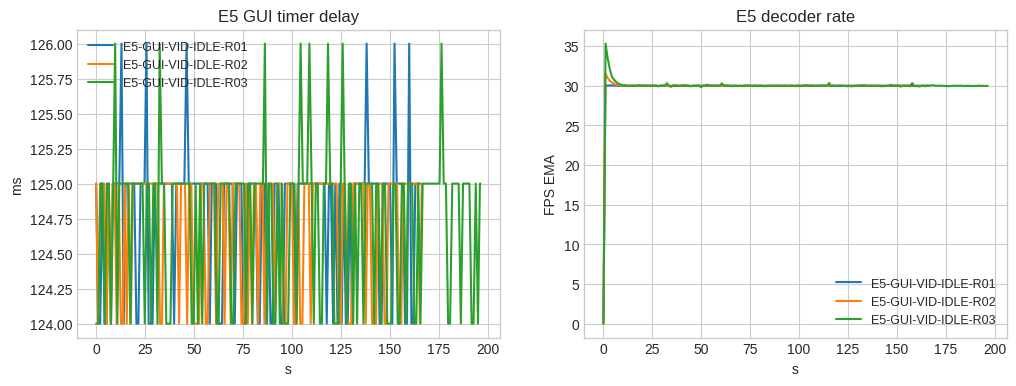


E6 — grounded keyboard RC
run | duration_s | rc_packets | cadence_med | gap_p95 | gap_max | nonzero | pulses | pulse_med | neutral_max | blackouts | safety | unsafe_nonzero | link_nonOK | sources
E6-RC-IDLE-R01 | 96.69 | 923 | 100.0 | 101.0 | 151.0 | 19 | 8 | 125.5 | 151.0 | 0 | 0 | 0 | 0 | keyboard-neutral,keyboard-worker
E6-RC-IDLE-R02 | 102.84 | 929 | 100.0 | 101.0 | 151.0 | 39 | 8 | 401.0 | 150.0 | 0 | 0 | 0 | 0 | keyboard-neutral,keyboard-worker
E6-RC-IDLE-R03 | 105.36 | 1017 | 100.0 | 101.0 | 151.0 | 43 | 8 | 401.0 | 101.0 | 0 | 0 | 0 | 0 | keyboard-neutral,keyboard-worker
Saved: /home/gabriel/CS-500/results/final_repeated/analysis_images/e6_rc_idle_analysis.png


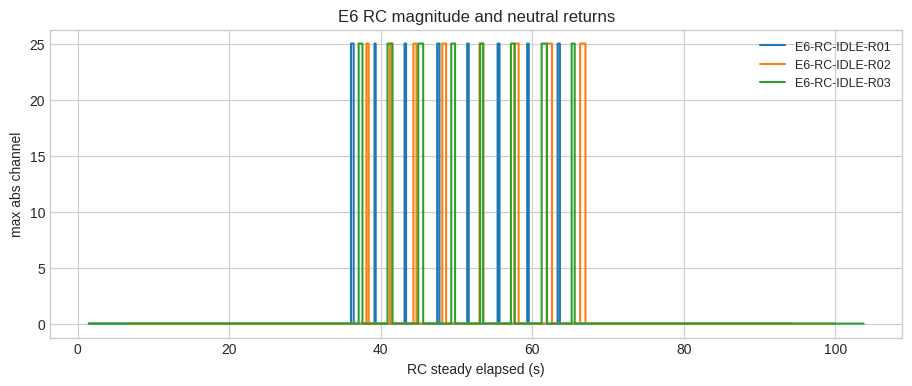


E7 — keyboard response in flight
run | duration_s | rc_packets | cadence_med | gap_p95 | gap_max | nonzero_vertical | nonzero_yaw | nonzero_horizontal | takeoff_confirmed | land_OK | touchdown_seen | tel_age_p95 | vid_age_p95 | fps_med | decoder_err | gui_tick_p95 | command_mutex_p95 | tel_nonOK | vid_nonOK | link_nonOK | safety | unsafe_nonzero
E7-KBD-RESPONSE-R01 | 101.74 | 750 | 100.0 | 130.4 | 200.0 | 11 | 17 | 40 | True | True | True | 95.9 | 31.95 | 30.001 | 13 | 125.0 | 0.0 | 0 | 0 | 2 | 0 | 0
E7-KBD-RESPONSE-R02 | 107.87 | 879 | 100.0 | 150.0 | 250.0 | 15 | 15 | 47 | True | True | True | 97.0 | 32.65 | 30.002 | 25 | 125.0 | 0.0 | 0 | 0 | 0 | 0 | 0
E7-KBD-RESPONSE-R03 | 127.92 | 1096 | 100.0 | 101.0 | 201.0 | 26 | 16 | 45 | True | True | True | 97.0 | 30.35 | 30.006 | 10 | 125.0 | 0.0 | 0 | 0 | 0 | 0 | 0
Saved: /home/gabriel/CS-500/results/final_repeated/analysis_images/e7_flight_response_analysis.png


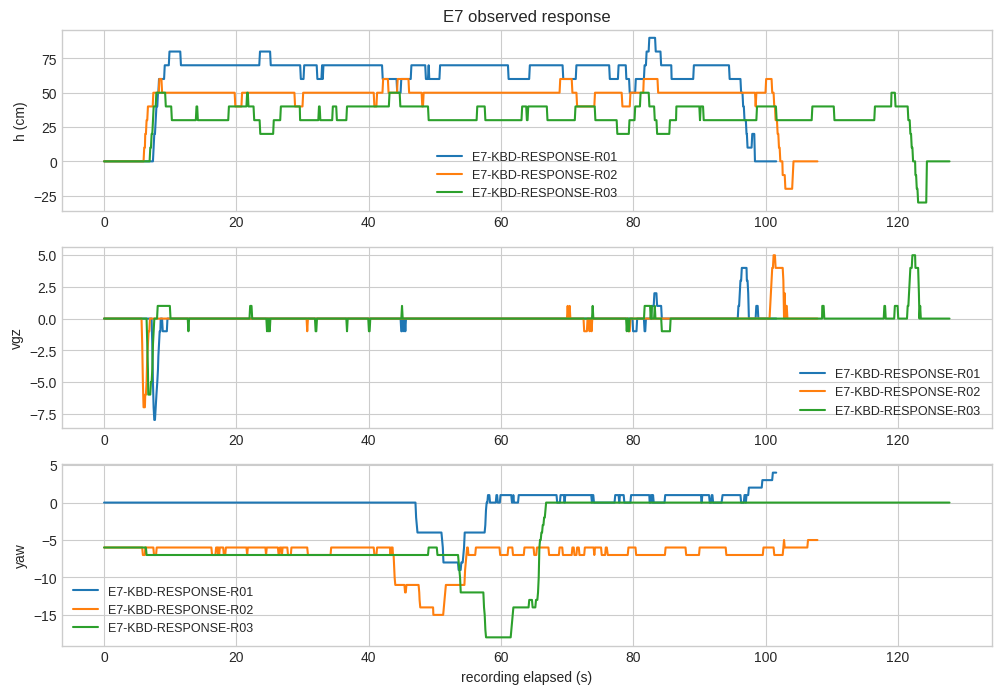


E8 — drone power cycle
run | duration_s | onset_s | command_restore_s | telemetry_restore_s | video_restore_s | attempt_rows | timeout_rows | hard | stages | results | final
E8-PWR-CYCLE-R01 | 84.6 | 33.33 | 18.263 | 19.263 | 19.263 | 3 | 2 | True | power_command>power_streamon | OK>TIMEOUT>OK | CONNECTED/OK/OK/OK
E8-PWR-CYCLE-R02 | 83.56 | 33.322 | 18.238 | 19.238 | 20.238 | 3 | 2 | True | power_command>power_streamon | OK>TIMEOUT>OK | CONNECTED/OK/OK/OK
E8-PWR-CYCLE-R03 | 83.58 | 33.335 | 18.236 | 19.237 | 20.237 | 3 | 2 | True | power_command>power_streamon | OK>TIMEOUT>OK | CONNECTED/OK/OK/OK
Saved: /home/gabriel/CS-500/results/final_repeated/analysis_images/e8_power_cycle_recovery.png


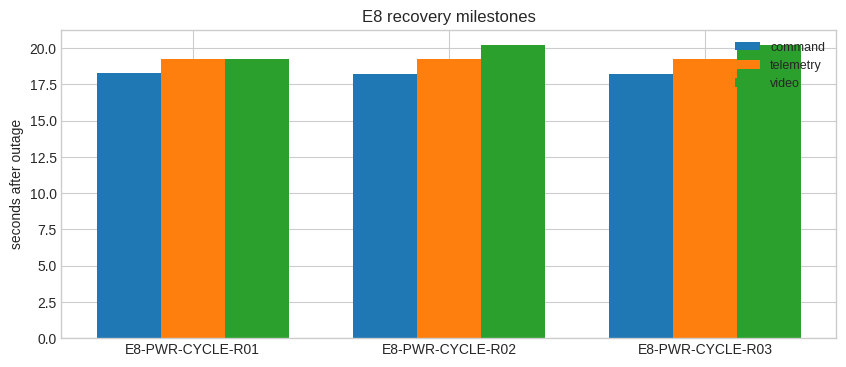


E9 — host Wi-Fi loss
run | duration_s | lost_at_s | reconnect_s | failed_commands | timeout_rows | stale_rows | error_rows | state_sequence | outage_count | final_command | recovery | final
E9-WIFI-LOSS-R01 | 81.93 | 34.96 | 19.425 | 4 | 2 | 4 | 0 | CONNECTED>RECOVERING>CONNECTED | 1 | OK | False | CONNECTED/OK/NO_DATA/NO_DATA
E9-WIFI-LOSS-R02 | 81.95 | 34.949 | 19.455 | 4 | 2 | 4 | 0 | CONNECTED>RECOVERING>CONNECTED | 1 | OK | False | CONNECTED/OK/NO_DATA/NO_DATA
E9-WIFI-LOSS-R03 | 80.93 | 36.997 | 10.276 | 2 | 0 | 2 | 0 | CONNECTED>RECOVERING>CONNECTED | 1 | OK | False | CONNECTED/OK/NO_DATA/NO_DATA
Saved: /home/gabriel/CS-500/results/final_repeated/analysis_images/e9_wifi_reconnect.png


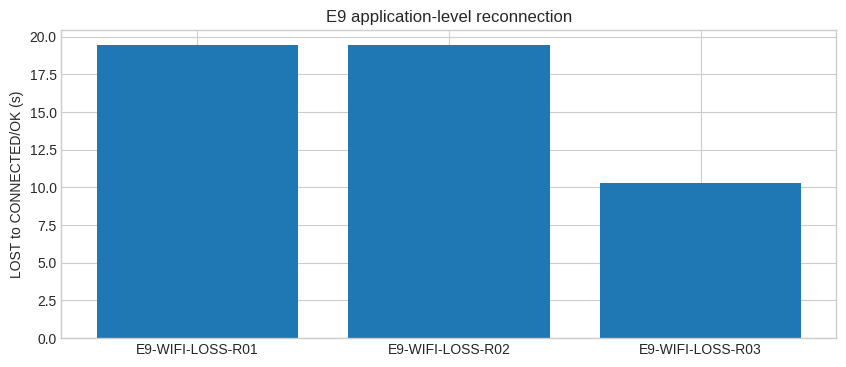

In [49]:
def exp_paths(prefix, state=False):
    return [p for p in sorted(DATA_DIR.glob(f"{prefix}*.csv")) if p.name.endswith("-state.csv") == state]
def vals(rows, field):
    return [number(r,field) for r in rows if math.isfinite(number(r,field))]
def run_id(path):
    m=re.search(r"(R\\d+)",path.stem); return m.group(1) if m else path.stem
def first_ms(rows,predicate):
    return next((number(r,"elapsed_ms") for r in rows if predicate(r)),math.nan)
def transitions(rows,field):
    out=[]
    for row in rows:
        value=row.get(field,"")
        if value and (not out or value!=out[-1]): out.append(value)
    return ">".join(out)
def table(records,fields):
    print(" | ".join(fields))
    for r in records: print(" | ".join(str(r.get(f,"")) for f in fields))
def rc_obs(state):
    out=[]; seen=set()
    for r in state:
        seq=int(number(r,"rc_sequence",-1)); ms=number(r,"rc_steady_elapsed_ms",-1)
        if seq<0 or ms<0 or seq in seen: continue
        seen.add(seq)
        vec=tuple(int(number(r,k,0)) for k in ("rc_a","rc_b","rc_c","rc_d"))
        out.append((ms,seq,vec,r.get("rc_result"),r.get("rc_source")))
    return sorted(out)
def pulse_summary(obs):
    starts=[]; active=None; returns=[]
    for ms,seq,vec,result,source in obs:
        if any(vec) and active is None: active=[ms,ms,vec]
        elif any(vec) and vec==active[2]: active[1]=ms
        elif active is not None:
            starts.append(active[1]-active[0])
            if not any(vec): returns.append(ms-active[1])
            active=[ms,ms,vec] if any(vec) else None
    if active is not None: starts.append(active[1]-active[0])
    return starts,returns

print("\nE1 — connectivity smoke gate")
e1=[]
for p in sorted(DATA_DIR.glob("E1-SMOKE-CMD*.csv")):
    rows=read_csv_rows(p); r=rows[-1]
    e1.append({"run":p.stem,"success":int(number(r,"command_successes",0)),"failure":int(number(r,"command_failures",0)),
               "retry":int(number(r,"command_retry_count",0)),"timeout":int(number(r,"command_timeout_count",0)),
               "result":r.get("last_command_result"),"connection":r.get("connection_state"),"response":r.get("last_response")})
table(e1,["run","success","failure","retry","timeout","result","connection","response"])
print("gate", "PASS" if e1 and all(r["success"]>=1 and r["failure"]==r["retry"]==r["timeout"]==0 and r["result"]=="OK" for r in e1) else "REVIEW")

print("\nE5 — GUI + video idle")
e5=[]; e5plot={}
for p in exp_paths("E5-GUI-VID-IDLE-R"):
    rows=read_csv_rows(p); state=read_csv_rows(p.with_name(p.stem+"-state.csv")); rid=run_id(p); e5plot[rid]=rows
    converted=max(vals(rows,"ui_frames_converted") or [0]); displayed=max(vals(rows,"ui_frames_displayed") or [0])
    e5.append({"run":rid,"duration_s":round(number(rows[-1],"elapsed_ms")/1000,2),
      "state_hz":round(len(state)/(number(state[-1],"recording_elapsed_ms")/1000),2),
      "tel_age_p95":round(percentile(vals(rows,"telemetry_age_ms"),95),2),"vid_age_p95":round(percentile(vals(rows,"video_age_ms"),95),2),
      "fps_med":round(percentile(vals(rows,"decoder_fps_ema"),50),3),"decoder_err":int(max(vals(rows,"decoder_errors") or [0])),
      "vision_tick_p95":round(percentile(vals(rows,"gui_vision_tick_delay_ms"),95),2),"vision_tick_max":round(max(vals(rows,"gui_vision_tick_delay_ms") or [math.nan]),2),
      "state_tick_p95":round(percentile(vals(rows,"gui_state_tick_delay_ms"),95),2),"state_tick_max":round(max(vals(rows,"gui_state_tick_delay_ms") or [math.nan]),2),
      "refresh_p95":round(percentile(vals(rows,"vision_refresh_duration_ms"),95),2),
      "convert_p95":round(percentile(vals(rows,"frame_convert_ms"),95),2),"scale_p95":round(percentile(vals(rows,"frame_scale_ms"),95),2),
      "paint_p95":round(percentile(vals(rows,"plot_paint_ms"),95),2),"mutex_p95":round(percentile(vals(rows,"vision_frame_mutex_wait_ms"),95),3),
      "command_mutex_p95":round(percentile(vals(rows,"command_mutex_wait_ms"),95),3),"state_gap_p95":round(percentile(np.diff(vals(state,"recording_elapsed_ms")),95),2),
      "state_gap_max":round(max(np.diff(vals(state,"recording_elapsed_ms"))),2),"display_pct":round(100*displayed/converted,2) if converted else math.nan,"ui_drop":int(max(vals(rows,"ui_frames_dropped") or [0])),
      "tel_nonOK":sum(r.get("telemetry_quality")!="OK" for r in rows),"vid_nonOK":sum(r.get("video_quality")!="OK" for r in rows),
      "state_gaps":sum(max(0,int(number(state[i],"state_sequence")-number(state[i-1],"state_sequence")-1)) for i in range(1,len(state)))})
table(e5,["run","duration_s","state_hz","tel_age_p95","vid_age_p95","fps_med","decoder_err","vision_tick_p95","vision_tick_max",
          "state_tick_p95","state_tick_max","refresh_p95","convert_p95","scale_p95","paint_p95","mutex_p95","command_mutex_p95","state_gap_p95","state_gap_max","display_pct","ui_drop","tel_nonOK","vid_nonOK","state_gaps"])
fig,ax=plt.subplots(1,2,figsize=(12,4))
for rid,rows in e5plot.items():
    t=np.asarray(vals(rows,"elapsed_ms"))/1000; ax[0].plot(t,vals(rows,"gui_vision_tick_delay_ms"),label=rid); ax[1].plot(t,vals(rows,"decoder_fps_ema"),label=rid)
ax[0].set(title="E5 GUI timer delay",xlabel="s",ylabel="ms"); ax[1].set(title="E5 decoder rate",xlabel="s",ylabel="FPS EMA")
for a in ax:a.legend()
save_figure(fig,"e5_gui_idle_analysis.png"); plt.show()

print("\nE6 — grounded keyboard RC")
e6=[]; e6plot={}
for p in exp_paths("E6-RC-IDLE-R"):
    rows=read_csv_rows(p); state=read_csv_rows(p.with_name(p.stem+"-state.csv")); obs=rc_obs(state); gaps=np.diff([o[0] for o in obs]); pulses,returns=pulse_summary(obs)
    rid=run_id(p); e6plot[rid]=obs
    e6.append({"run":rid,"duration_s":round(number(rows[-1],"elapsed_ms")/1000,2),"rc_packets":len(obs),
      "cadence_med":round(percentile(gaps,50),2),"gap_p95":round(percentile(gaps,95),2),"gap_max":round(max(gaps) if len(gaps) else math.nan,2),
      "nonzero":sum(any(o[2]) for o in obs),"pulses":len(pulses),"pulse_med":round(percentile(pulses,50),2),
      "neutral_max":round(max(returns) if returns else math.nan,2),"blackouts":int(max(vals(rows,"rc_blackout_count") or [0])),
      "safety":int(max(vals(rows,"rc_safety_override_active") or [0])),"unsafe_nonzero":sum(any(number(r,k,0)!=0 for k in ("rc_left_right","rc_forward_back","rc_up_down","rc_yaw")) and number(r,"link_safe_for_nonzero_rc",0)==0 for r in rows),"link_nonOK":sum(r.get("link_quality")!="OK" for r in rows),
      "sources":",".join(sorted({o[4] for o in obs if o[4]}))})
table(e6,["run","duration_s","rc_packets","cadence_med","gap_p95","gap_max","nonzero","pulses","pulse_med","neutral_max","blackouts","safety","unsafe_nonzero","link_nonOK","sources"])
fig,ax=plt.subplots(figsize=(11,4))
for rid,obs in e6plot.items(): ax.step([o[0]/1000 for o in obs],[max(abs(x) for x in o[2]) for o in obs],where="post",label=rid)
ax.set(title="E6 RC magnitude and neutral returns",xlabel="RC steady elapsed (s)",ylabel="max abs channel"); ax.legend()
save_figure(fig,"e6_rc_idle_analysis.png"); plt.show()

print("\nE7 — keyboard response in flight")
e7=[]; e7plot={}
for p in exp_paths("E7-KBD-RESPONSE-R"):
    rows=read_csv_rows(p); state=read_csv_rows(p.with_name(p.stem+"-state.csv")); obs=rc_obs(state); gaps=np.diff([o[0] for o in obs]); pulses,returns=pulse_summary(obs); rid=run_id(p); e7plot[rid]=state
    active=[o for o in obs if any(o[2])]; vertical=sum(o[2][2]!=0 for o in active); yaw_cmd=sum(o[2][3]!=0 for o in active); horizontal=sum((o[2][0]!=0 or o[2][1]!=0) for o in active)
    e7.append({"run":rid,"duration_s":round(number(rows[-1],"elapsed_ms")/1000,2),"rc_packets":len(obs),"cadence_med":round(percentile(gaps,50),2),
      "gap_p95":round(percentile(gaps,95),2),"gap_max":round(max(gaps) if len(gaps) else math.nan,2),"nonzero_vertical":vertical,"nonzero_yaw":yaw_cmd,
      "nonzero_horizontal":horizontal,"takeoff_confirmed":any("telemetry_confirmed(takeoff" in r.get("log_message","") for r in rows),
      "land_OK":any(r.get("last_command","").lower()=="land" and r.get("last_command_result")=="OK" for r in rows),
      "touchdown_seen":any(number(r,"h")<=10 and number(r,"tof")<=20 for r in state[-20:]),"tel_nonOK":sum(r.get("telemetry_quality")!="OK" for r in rows),
      "vid_nonOK":sum(r.get("video_quality")!="OK" for r in rows),"link_nonOK":sum(r.get("link_quality")!="OK" for r in rows),
      "safety":int(max(vals(rows,"rc_safety_override_active") or [0])),"tel_age_p95":round(percentile(vals(rows,"telemetry_age_ms"),95),2),
      "vid_age_p95":round(percentile(vals(rows,"video_age_ms"),95),2),"fps_med":round(percentile(vals(rows,"decoder_fps_ema"),50),3),
      "decoder_err":int(max(vals(rows,"decoder_errors") or [0])),"gui_tick_p95":round(percentile(vals(rows,"gui_vision_tick_delay_ms"),95),2),
      "command_mutex_p95":round(percentile(vals(rows,"command_mutex_wait_ms"),95),3),"unsafe_nonzero":sum(any(number(r,k,0)!=0 for k in ("rc_left_right","rc_forward_back","rc_up_down","rc_yaw")) and number(r,"link_safe_for_nonzero_rc",0)==0 for r in rows)})
table(e7,["run","duration_s","rc_packets","cadence_med","gap_p95","gap_max","nonzero_vertical","nonzero_yaw","nonzero_horizontal",
          "takeoff_confirmed","land_OK","touchdown_seen","tel_age_p95","vid_age_p95","fps_med","decoder_err","gui_tick_p95","command_mutex_p95","tel_nonOK","vid_nonOK","link_nonOK","safety","unsafe_nonzero"])
fig,ax=plt.subplots(3,1,figsize=(12,8))
for rid,state in e7plot.items():
    t=np.asarray(vals(state,"recording_elapsed_ms"))/1000
    ax[0].plot(t,vals(state,"h"),label=rid); ax[1].plot(t,vals(state,"vgz"),label=rid); ax[2].plot(t,vals(state,"yaw"),label=rid)
ax[0].set(ylabel="h (cm)",title="E7 observed response"); ax[1].set(ylabel="vgz"); ax[2].set(ylabel="yaw",xlabel="recording elapsed (s)")
for a in ax:a.legend()
save_figure(fig,"e7_flight_response_analysis.png"); plt.show()

print("\nE8 — drone power cycle")
e8=[]
for p in exp_paths("E8-PWR-CYCLE-R"):
    rows=read_csv_rows(p); onset=first_ms(rows,lambda r:r.get("link_quality")!="OK")
    cmd=first_ms(rows,lambda r:number(r,"elapsed_ms")>onset and number(r,"recovery_attempted",0)>0 and r.get("recovery_result")=="OK")
    tel=first_ms(rows,lambda r:number(r,"elapsed_ms")>onset and r.get("telemetry_quality")=="OK")
    vid=first_ms(rows,lambda r:number(r,"elapsed_ms")>onset and r.get("video_quality")=="OK"); last=rows[-1]
    e8.append({"run":run_id(p),"duration_s":round(number(last,"elapsed_ms")/1000,2),"onset_s":round(onset/1000,3),
      "command_restore_s":round((cmd-onset)/1000,3),"telemetry_restore_s":round((tel-onset)/1000,3),"video_restore_s":round((vid-onset)/1000,3),
      "attempt_rows":sum(number(r,"recovery_attempted",0)>0 for r in rows),"timeout_rows":sum(r.get("recovery_result")=="TIMEOUT" for r in rows),
      "hard":any(number(r,"recovery_hard",0)>0 for r in rows),"stages":">".join(dict.fromkeys(r.get("recovery_stage","") for r in rows if r.get("recovery_stage"))),"results":transitions(rows,"recovery_result"),"final":"/".join(last.get(k,"") for k in ("connection_state","link_quality","telemetry_quality","video_quality"))})
table(e8,["run","duration_s","onset_s","command_restore_s","telemetry_restore_s","video_restore_s","attempt_rows","timeout_rows","hard","stages","results","final"])
fig,ax=plt.subplots(figsize=(10,4)); x=np.arange(len(e8)); w=.25
for i,(f,l) in enumerate((("command_restore_s","command"),("telemetry_restore_s","telemetry"),("video_restore_s","video"))): ax.bar(x+(i-1)*w,[r[f] for r in e8],w,label=l)
ax.set_xticks(x,[r["run"] for r in e8]); ax.set(title="E8 recovery milestones",ylabel="seconds after outage"); ax.legend()
save_figure(fig,"e8_power_cycle_recovery.png"); plt.show()

print("\nE9 — host Wi-Fi loss")
e9=[]
for p in exp_paths("E9-WIFI-LOSS-R"):
    rows=read_csv_rows(p); lost=first_ms(rows,lambda r:r.get("event")=="LOST")
    restored=first_ms(rows,lambda r:number(r,"elapsed_ms")>lost and r.get("last_command_result")=="OK")
    outage=[r for r in rows if lost<=number(r,"elapsed_ms")<=restored]; last=rows[-1]
    e9.append({"run":run_id(p),"duration_s":round(number(last,"elapsed_ms")/1000,2),"lost_at_s":round(lost/1000,3),"reconnect_s":round((restored-lost)/1000,3),
      "failed_commands":sum(r.get("last_command_result") in ("ERROR","TIMEOUT") for r in outage),"timeout_rows":sum(r.get("last_command_result")=="TIMEOUT" for r in outage),
      "stale_rows":sum(r.get("link_quality")=="STALE" for r in outage),"error_rows":sum(r.get("link_quality")=="ERROR" for r in outage),
      "state_sequence":transitions(rows,"connection_state"),"outage_count":sum(r.get("event")=="LOST" for r in rows),"final_command":last.get("last_command_result"),"recovery":any(number(r,"recovery_attempted",0)>0 for r in rows),"final":"/".join(last.get(k,"") for k in ("connection_state","link_quality","telemetry_quality","video_quality"))})
table(e9,["run","duration_s","lost_at_s","reconnect_s","failed_commands","timeout_rows","stale_rows","error_rows","state_sequence","outage_count","final_command","recovery","final"])
fig,ax=plt.subplots(figsize=(10,4)); ax.bar([r["run"] for r in e9],[r["reconnect_s"] for r in e9])
ax.set(title="E9 application-level reconnection",ylabel="LOST to CONNECTED/OK (s)")
save_figure(fig,"e9_wifi_reconnect.png"); plt.show()

### Quantitative Results for E5-E9

- **E5:** all three runs kept telemetry and video at OK for every sampled row, with decoder medians of 29.999-30.002 fps and p95 ages of 95.5-98.0 ms (telemetry) and 31-32 ms (video). Vision/state timer p95 values were 125/250 ms, their configured scheduling periods; refresh p95 was 2 ms, scaling p95 1 ms, and both mutex-wait p95 values were 0 ms. State recording remained near 9.95-9.96 Hz with zero sequence gaps; maximum inter-sample gaps were 155, 212, and 155 ms. UI accounting displayed 88.12-90.44% of converted frames and reported 3,635-4,234 dropped display opportunities.
- **E6:** each run contained eight nonzero RC pulses. Deduplicated RC cadence had a 100 ms median, 101 ms p95, and 151 ms maximum. Every pulse returned to neutral within 101-151 ms; no RC blackout, safety override, unsafe nonzero command, or non-OK link row was recorded. Pulse medians were 125.5 ms in R01 and 401 ms in R02/R03, so R01 did not reproduce the intended approximately 500 ms hold duration.
- **E7:** RC cadence remained centered at 100 ms; p95/max gaps were 130.4/200, 150/250, and 101/201 ms. All runs show telemetry-confirmed takeoff, an OK landing command, terminal height/ToF consistent with touchdown, telemetry/video entirely OK, decoder medians near 30 fps, and no unsafe nonzero RC. R01 alone contained two non-OK link samples; no RC safety override was activated.
- **E8:** recovery succeeded in 3/3 power-cycle trials. Command restoration occurred 18.236-18.263 s after outage onset, telemetry at 19.237-19.263 s, and video at 19.263-20.238 s. Each run recorded two TIMEOUT recovery rows followed by OK, used the power_command then power_streamon stages, set hard recovery, and ended CONNECTED/OK/OK/OK.
- **E9:** reconnect succeeded in 3/3 host-Wi-Fi trials. The first successful command followed the LOST event after 19.425, 19.455, and 10.276 s. R01/R02 recorded four failed-command rows including two timeouts; R03 recorded two errors and no timeout. Every run recorded one LOST event, traversed CONNECTED → RECOVERING → CONNECTED, and ended with command result OK. Telemetry/video remain NO_DATA by design because E9 used command-only watch mode.

## Interpretation of E5-E9

E5 jointly tests transport continuity and GUI scheduling: timer maxima expose transient UI stalls that a median would hide, while decoder rate and quality labels distinguish rendering cost from network loss. E6 uses deduplicated RC sequences to verify cadence, bounded nonzero pulses, neutral return, link state, blackout counters, and safety overrides. E7 adds flight traces and distinguishes telemetry-confirmed takeoff from its synchronous acknowledgment, successful landing command from observed touchdown, and commanded axes from the available motion proxies. E8 times recovery from the first non-OK link sample through command, telemetry, and video restoration. E9 requires both CONNECTED and link OK, so Wi-Fi association alone is not counted as application recovery. These rules preserve transient timeout evidence even when the final state succeeds.

## E10 — ROS 2 Integration Acceptance

E10 was exercised from a clean source-built ROS 2 Foxy workspace with the real drone online. The retained terminal output provides the following functional acceptance evidence:

| Check | Observed result | Interpretation |
|---|---|---|
| Application nodes | `/tello/tello_driver_node`, `/tello_control_panel_ros` | driver and shared ROS Control Panel were both discovered |
| Tello topics | 9 application topics | state, battery, connection, diagnostics, link quality, runtime metrics, video, autonomous velocity, and manual velocity surfaces were present |
| Tello services | 10 application services | connect/disconnect, takeoff/land/emergency, stream on/off, autonomy enable/disable, and GUI command forwarding were present |
| Live link samples | 2 consecutive samples, one second apart | the driver was actively publishing rather than merely advertising the topic |
| Overall health | `OK`, score `100` | aggregate online state passed |
| Component health | telemetry `OK`, video `OK`, command `OK` | the three active communication paths were healthy |
| RC state | `NO_DATA`, gap/age `-1`, 0 blackouts, override false | expected idle state because no manual RC stream was active |
| Nonzero-RC gate | `safe_for_nonzero_rc: true` | active channel health did not inhibit motion, although no RC actuation was tested |

Standard `/parameter_events`, `/rosout`, and per-node parameter services are infrastructure and are not counted in the application totals. Topic discovery alone does not prove message flow for every topic; however, the two live link-quality messages summarize current telemetry, decoded-video, and command health from the driver. The result therefore passes **qualitative functional E10 acceptance** for graph discovery, shared-GUI integration, and live channel health. Without a rosbag or `ros2 topic hz` capture, the notebook cannot compute ROS publish rates, end-to-end latency, callback health, active RC cadence, or recovery performance.

## Cross-Experiment Conclusions and Protocol Conformance

- E1 is the gate; E2 isolates commands; E3 telemetry; E4 CLI video; E5 GUI overhead; E6 grounded RC safety; E7 flight response; E8 and E9 drone-side and host-side recovery.
- E2-E3 provide the WSL2/native comparison. E4-E9 are native-only, consistent with discontinuing WSL2 after the command-path instability.
- E6 records the control source/profile as Default, whereas the protocol names KeyboardTest; aggression and mappings are not exported and cannot be independently verified.
- E6 lasts approximately 97-105 s rather than 120 s, E8 approximately 84 s rather than 180 s, and E9 approximately 81-82 s rather than 120 s. Conclusions apply to the recorded windows.
- E7 records telemetry-confirmed takeoff, successful landing commands, and terminal height/ToF samples consistent with touchdown in all three repetitions.
- E10 passes functional terminal acceptance: both application nodes, all expected Tello topics/services, and two live score-100 link-quality samples were observed. RC remained NO_DATA because no manual RC input was active.

Taken together, E1-E9 support stable native operation during ordinary command, telemetry, video, GUI, and RC workloads and demonstrate recovery in the recorded interruption trials. E10 adds qualitative real-drone evidence that the source-built ROS driver and shared Control Panel expose the intended graph and report healthy telemetry, video, and command paths. Remaining limitations concern protocol conformance and quantitative ROS evidence coverage, not a recurrence of the WSL2 periodic blackout.

## E7 Dynamic-Response Estimation

This repeated-flight analysis groups nonzero RC samples into pulses using monotonic timestamps. Response latency is measured from pulse onset to the first telemetry sample crossing an expected-direction threshold: 5 cm in height/ToF, 3 degrees in yaw, or 2 degrees in roll/pitch. Roll and pitch are attitude proxies because vgx/vgy remained near zero. With telemetry near 10 Hz, latency is an approximate upper-bound observation, not a fitted transfer function.

run | axis | motion | proxy | detected | total | median_ms | mean_ms | range_ms
R01 | rc_a | left/right | roll | 0 | 4 | nan | nan | --
R01 | rc_b | forward/back | pitch | 0 | 4 | nan | nan | --
R01 | rc_c | up/down | h/tof | 0 | 4 | nan | nan | --
R01 | rc_d | yaw | yaw | 4 | 4 | 417.0 | 401.8 | 328-445
R02 | rc_a | left/right | roll | 1 | 4 | 407.0 | 407.0 | 407-407
R02 | rc_b | forward/back | pitch | 4 | 4 | 470.0 | 473.8 | 341-614
R02 | rc_c | up/down | h/tof | 2 | 4 | 534.0 | 534.0 | 24-1044
R02 | rc_d | yaw | yaw | 4 | 4 | 371.5 | 378.0 | 322-447
R03 | rc_a | left/right | roll | 1 | 4 | 412.0 | 412.0 | 412-412
R03 | rc_b | forward/back | pitch | 0 | 4 | nan | nan | --
R03 | rc_c | up/down | h/tof | 4 | 5 | 713.0 | 638.8 | 310-819
R03 | rc_d | yaw | yaw | 4 | 4 | 331.5 | 347.0 | 317-408
Saved: /home/gabriel/CS-500/results/final_repeated/analysis_images/e7_rc_response_latency_repeated.png


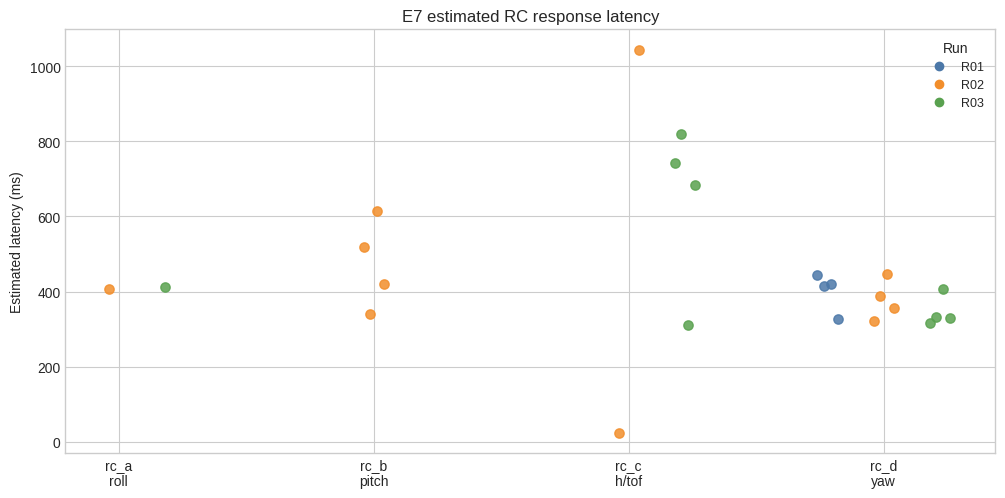

Saved: /home/gabriel/CS-500/results/final_repeated/analysis_images/e7_command_aligned_dynamics.png


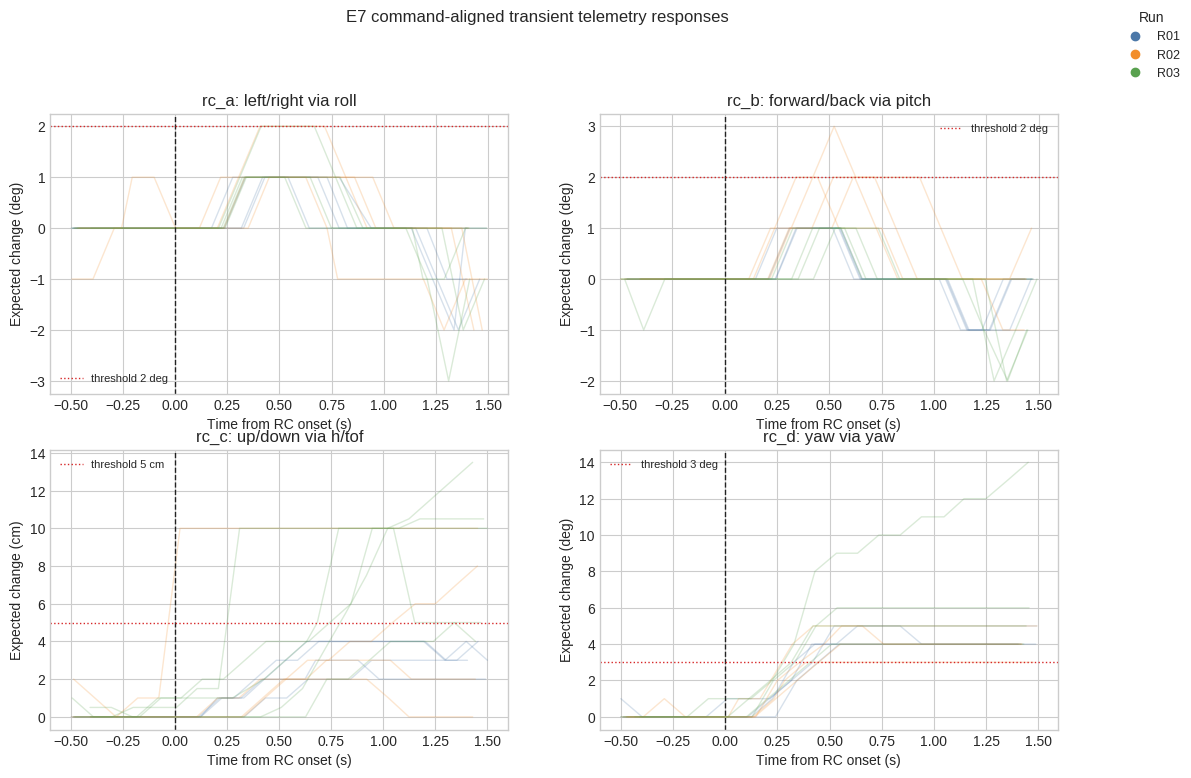

In [50]:
def e7_axis_pulses(state,idx,gap=300):
    out=[]; active=None
    for ms,seq,vec,result,source in rc_obs(state):
        value=vec[idx]; sign=1 if value>0 else (-1 if value<0 else 0)
        if sign==0:
            if active: out.append(active); active=None
        elif active and active["sign"]==sign and ms-active["last_ms"]<=gap:
            active["last_ms"]=active["end_ms"]=ms; active["samples"]+=1
        else:
            if active: out.append(active)
            active={"sign":sign,"value":value,"start_ms":ms,"end_ms":ms,"last_ms":ms,"samples":1}
    if active: out.append(active)
    return out

def e7_samples(state):
    fields=("h","tof","roll","pitch","yaw","vgx","vgy","vgz")
    return [{"t":number(r,"steady_elapsed_ms"),**{f:number(r,f) for f in fields}} for r in state if math.isfinite(number(r,"steady_elapsed_ms"))]
def e7_base(samples,field,start):
    return percentile([r[field] for r in samples if start-500<=r["t"]<=start],50)
def e7_angle(value,base): return (value-base+180)%360-180

E7_AXES={
 "rc_a":{"idx":0,"motion":"left/right","proxy":"roll","threshold":2.0,"unit":"deg","direction":lambda s:s},
 "rc_b":{"idx":1,"motion":"forward/back","proxy":"pitch","threshold":2.0,"unit":"deg","direction":lambda s:-s},
 "rc_c":{"idx":2,"motion":"up/down","proxy":"h/tof","threshold":5.0,"unit":"cm","direction":lambda s:s},
 "rc_d":{"idx":3,"motion":"yaw","proxy":"yaw","threshold":3.0,"unit":"deg","direction":lambda s:s}}

def e7_delta(sample,cfg,base,sign,base_tof=math.nan):
    d=cfg["direction"](sign)
    if cfg["proxy"]=="h/tof":
        dh=(sample["h"]-base)*d if math.isfinite(sample["h"]) and math.isfinite(base) else -math.inf
        dt=(sample["tof"]-base_tof)*d if math.isfinite(sample["tof"]) and math.isfinite(base_tof) else -math.inf
        return max(dh,dt)
    value=sample[cfg["proxy"]]
    if not math.isfinite(value) or not math.isfinite(base): return math.nan
    raw=e7_angle(value,base) if cfg["proxy"]=="yaw" else value-base
    return raw*d

def e7_responses(state,tolerance=750):
    samples=e7_samples(state); found=[]
    for axis,cfg in E7_AXES.items():
        for pulse in e7_axis_pulses(state,cfg["idx"]):
            field="h" if cfg["proxy"]=="h/tof" else cfg["proxy"]; base=e7_base(samples,field,pulse["start_ms"])
            base_tof=e7_base(samples,"tof",pulse["start_ms"]) if cfg["proxy"]=="h/tof" else math.nan
            for sample in samples:
                if not pulse["start_ms"]<=sample["t"]<=pulse["end_ms"]+tolerance: continue
                delta=e7_delta(sample,cfg,base,pulse["sign"],base_tof)
                if math.isfinite(delta) and delta>=cfg["threshold"]:
                    found.append({**pulse,"axis":axis,"motion":cfg["motion"],"proxy":cfg["proxy"],"delta":delta,"latency_ms":sample["t"]-pulse["start_ms"]}); break
    return found

e7_states={}; e7_response_rows=[]; e7_response_summary=[]
for path in exp_paths("E7-KBD-RESPONSE-R"):
    rid=path.stem.rsplit("-",1)[-1]; state=read_csv_rows(path.with_name(path.stem+"-state.csv")); e7_states[rid]=state; detected=e7_responses(state)
    e7_response_rows.extend({"run":rid,**r} for r in detected)
    for axis,cfg in E7_AXES.items():
        lat=[r["latency_ms"] for r in detected if r["axis"]==axis]; total=len(e7_axis_pulses(state,cfg["idx"]))
        e7_response_summary.append({"run":rid,"axis":axis,"motion":cfg["motion"],"proxy":cfg["proxy"],"detected":len(lat),"total":total,
          "median_ms":round(percentile(lat,50),1),"mean_ms":round(float(np.mean(lat)),1) if lat else math.nan,
          "range_ms":f"{min(lat):.0f}-{max(lat):.0f}" if lat else "--"})
table(e7_response_summary,["run","axis","motion","proxy","detected","total","median_ms","mean_ms","range_ms"])

colors={"R01":"#4C78A8","R02":"#F28E2B","R03":"#59A14F"}; offsets={"R01":-.22,"R02":0,"R03":.22}
fig,ax=plt.subplots(figsize=(12,5.5))
for i,axis in enumerate(E7_AXES,1):
    for rid in offsets:
        y=[r["latency_ms"] for r in e7_response_rows if r["axis"]==axis and r["run"]==rid]
        if y: ax.scatter(i+offsets[rid]+np.linspace(-.04,.04,len(y)),y,color=colors[rid],label=rid if i==1 else None,s=45,alpha=.85)
ax.set_xticks(range(1,5),[f'{a}\n{E7_AXES[a]["proxy"]}' for a in E7_AXES]); ax.set(title="E7 estimated RC response latency",ylabel="Estimated latency (ms)"); run_handles=[plt.Line2D([],[],marker="o",linestyle="None",color=colors[r],label=r) for r in ("R01","R02","R03")]; ax.legend(handles=run_handles,title="Run")
save_figure(fig,"e7_rc_response_latency_repeated.png"); plt.show()

fig,axes=plt.subplots(2,2,figsize=(13,8)); axes=axes.ravel()
for ax,(axis,cfg) in zip(axes,E7_AXES.items()):
    for rid,state in e7_states.items():
        samples=e7_samples(state)
        for pulse in e7_axis_pulses(state,cfg["idx"]):
            field="h" if cfg["proxy"]=="h/tof" else cfg["proxy"]; base=e7_base(samples,field,pulse["start_ms"])
            base_tof=e7_base(samples,"tof",pulse["start_ms"]) if cfg["proxy"]=="h/tof" else math.nan
            xy=[((s["t"]-pulse["start_ms"])/1000,e7_delta(s,cfg,base,pulse["sign"],base_tof)) for s in samples if pulse["start_ms"]-500<=s["t"]<=pulse["start_ms"]+1500]
            xy=[p for p in xy if math.isfinite(p[1])]
            if xy: ax.plot([p[0] for p in xy],[p[1] for p in xy],color=colors[rid],alpha=.22,lw=1)
    ax.axvline(0,color="#222222",ls="--",lw=1); ax.axhline(cfg["threshold"],color="#D62728",ls=":",lw=1,label=f'threshold {cfg["threshold"]:g} {cfg["unit"]}')
    ax.set(title=f'{axis}: {cfg["motion"]} via {cfg["proxy"]}',xlabel="Time from RC onset (s)",ylabel=f'Expected change ({cfg["unit"]})'); ax.legend(fontsize=8)
fig.suptitle("E7 command-aligned transient telemetry responses",y=1.01); fig.legend(handles=run_handles,loc="upper right",title="Run")
save_figure(fig,"e7_command_aligned_dynamics.png"); plt.show()

### E7 Complete State Matrix

This single 5×3 matrix overlays all three repeated flights relative to telemetry-detected takeoff. It shows the 15 principal SDK state variables used in the previous analysis: attitude, velocity, distance/altitude, battery, temperature, and acceleration.

Saved: /home/gabriel/CS-500/results/final_repeated/analysis_images/e7_all_state_subplots_repeated.png


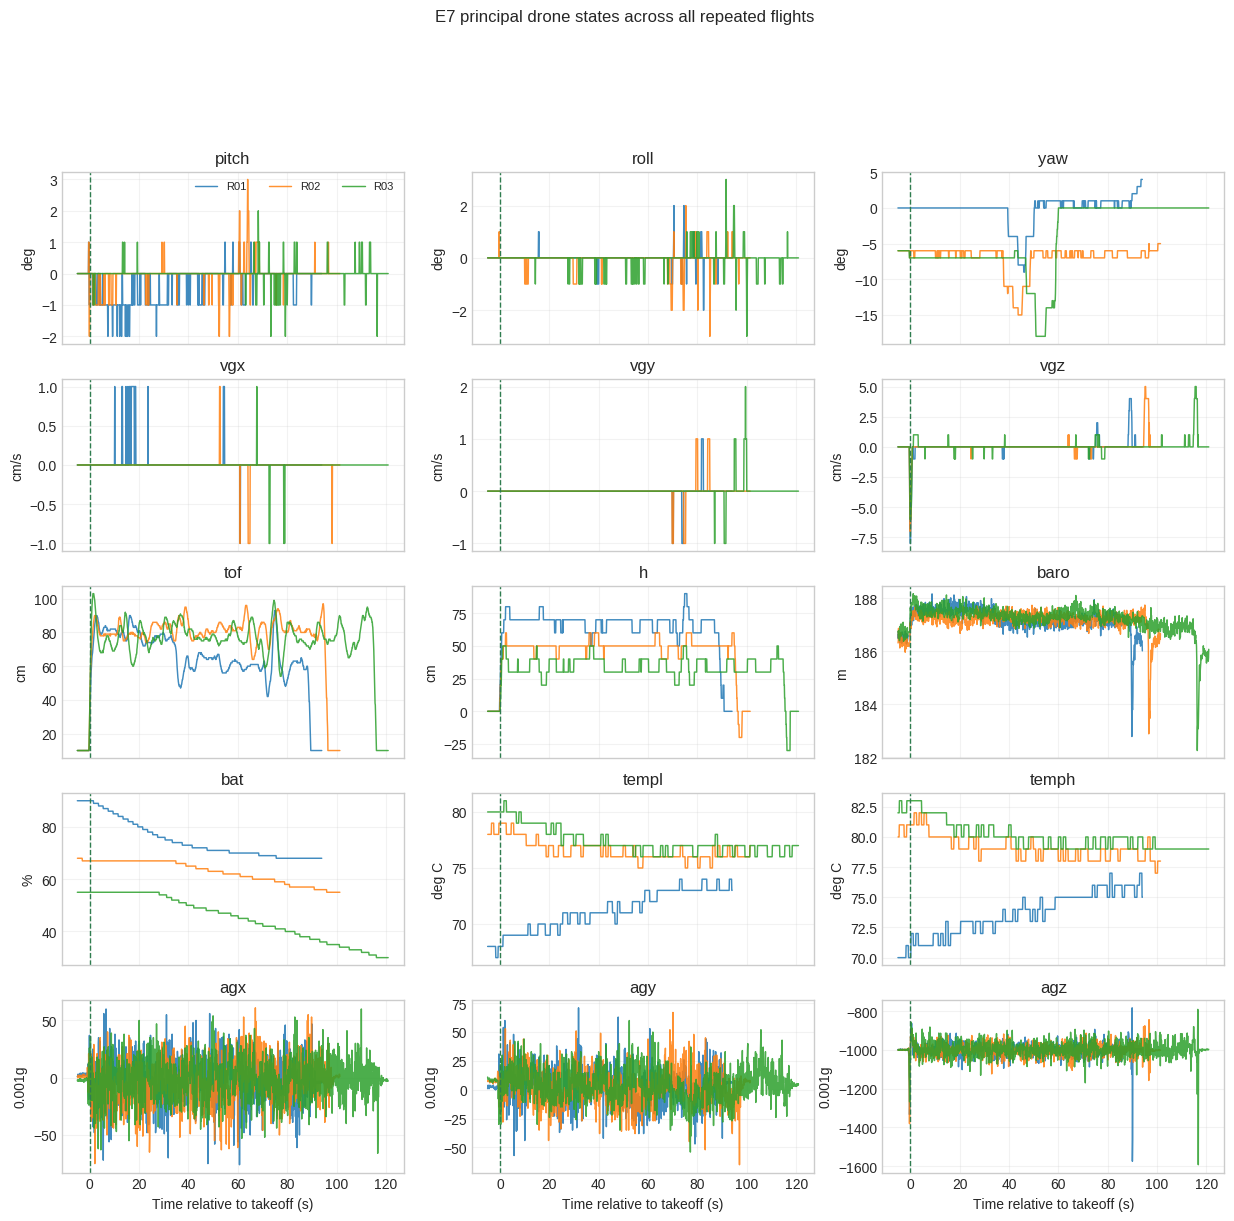

run | takeoff_s | touchdown_s | airborne_s
R01 | 7.59 | 97.28 | 89.68
R02 | 6.07 | 102.44 | 96.37
R03 | 6.78 | 122.76 | 115.97


In [51]:
def e7_markers(state):
    points=[(number(r,"steady_elapsed_ms")/1000,number(r,"h"),number(r,"tof")) for r in state if math.isfinite(number(r,"steady_elapsed_ms"))]
    takeoff=touchdown=math.nan
    for i in range(len(points)-2):
        w=points[i:i+3]
        if w[0][0]>=5 and all(h>=20 or tof>=30 for _,h,tof in w): takeoff=w[0][0]; break
    if math.isfinite(takeoff):
        for i in range(len(points)-2):
            w=points[i:i+3]
            if w[0][0]>=takeoff+20 and all(h<=10 and tof<=25 for _,h,tof in w): touchdown=w[0][0]; break
    return takeoff,touchdown

state_cols=[("pitch","deg"),("roll","deg"),("yaw","deg"),("vgx","cm/s"),("vgy","cm/s"),("vgz","cm/s"),
            ("tof","cm"),("h","cm"),("baro","cm"),("bat","%"),("templ","deg C"),("temph","deg C"),
            ("agx","0.001g"),("agy","0.001g"),("agz","0.001g")]
fig,axes=plt.subplots(5,3,figsize=(15,13),sharex=True); axes=axes.ravel(); e7_markers_summary=[]
for rid,state in e7_states.items():
    takeoff,touchdown=e7_markers(state); e7_markers_summary.append({"run":rid,"takeoff_s":round(takeoff,2),"touchdown_s":round(touchdown,2),"airborne_s":round(touchdown-takeoff,2)})
    t=np.asarray([number(r,"steady_elapsed_ms")/1000-takeoff for r in state])
    for ax,(field,unit) in zip(axes,state_cols):
        y=np.asarray([number(r,field) for r in state]); mask=np.isfinite(t)&np.isfinite(y)&(t>=-5)&(t<=touchdown-takeoff+5)
        ax.plot(t[mask],y[mask],label=rid,lw=1.05,alpha=.85)
for ax,(field,unit) in zip(axes,state_cols):
    ax.axvline(0,color="#2F7D4F",ls="--",lw=1); ax.set_title(field); ax.set_ylabel(unit); ax.grid(alpha=.25)
for ax in axes[-3:]: ax.set_xlabel("Time relative to takeoff (s)")
axes[0].legend(ncol=3,fontsize=8); fig.suptitle("E7 principal drone states across all repeated flights",y=1.005)
save_figure(fig,"e7_all_state_subplots_repeated.png"); plt.show()
table(e7_markers_summary,["run","takeoff_s","touchdown_s","airborne_s"])

### E7 Dynamic-Response Results

Across all repeated flights, yaw crossed the direct 3-degree threshold in 12/12 pulses, with a 371.5 ms median detected latency and 317-447 ms range. Vertical height/ToF crossed the 5 cm threshold in 6/13 pulses (713.0 ms median; 24-1,044 ms range). Roll crossed the lateral proxy threshold in 2/12 pulses (409.5 ms median), and pitch crossed the forward/back proxy threshold in 4/12 pulses (470.0 ms median; 341-614 ms range).

Sparse attitude-proxy detections do not prove absence of motion in the remaining pulses; they mean only that the selected proxy did not cross its conservative threshold within the pulse plus 750 ms. Telemetry-derived takeoff/touchdown markers were 7.59/97.28 s, 6.07/102.44 s, and 6.78/122.76 s for R01-R03. The state matrix confirms three physical flights and exposes the limited information content of vgx/vgy for horizontal dynamic estimation.